In [ ]:
# Title: 05_Xu_ElasticNet.ipynb
# Author: Lajoyce Mboning
# Date:2025
# Related publication: Emma K. Costa, and Jingxun Chen, in prep


# Description - Run the EN clock on Xu et al

# Set Up

In [ ]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import pearsonr
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import LeaveOneOut
from scipy.stats import ttest_ind, mannwhitneyu

In [ ]:
#allow Google CoLab to have access to your drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# set working dir
# Get current notebook's directory
notebook_dir = '/content/drive/My Drive/african_killifish_atlas/revisions/CodeCheck_revisions/Xu_model_outputs/ElasticNet/'

# Set working directory (here it's just confirming it's already set)
os.chdir(notebook_dir)

# Load and format Xu data - Brain

In [ ]:
df_counts_brain = pd.read_csv("../../Data_from_Others/AlanXu_Aging/CountsNormDESeq2_AlanXuAging_Brain_250605.csv")

df_counts_brain.head(5)

,Unnamed: 0,brain_10,brain_9,brain_8,brain_7,brain_6,brain_5,brain_4,brain_3,brain_20,...,brain_18,brain_17,brain_16,brain_15,brain_14,brain_13,brain_12,brain_11,brain_2,brain_1
0,nadsyn1,52.632452,90.607488,87.198380,105.548368,83.667637,81.614917,108.101921,112.420887,87.795380,...,95.452373,100.879093,113.855921,106.234929,89.641393,118.083136,76.614126,94.150684,104.883269,101.416672
1,dnaja3,178.415092,178.194727,188.929824,110.346021,135.409465,174.359140,214.712780,222.007635,198.694807,...,161.534785,104.914257,102.470329,140.984672,161.354507,125.890286,136.202891,132.666873,169.044814,177.557671
2,f2r,58.876980,58.894867,63.582152,81.560102,28.623139,39.570869,79.026232,94.471334,69.312142,...,88.109883,63.553829,55.892907,63.542387,75.298770,70.264345,47.292670,55.634495,105.081912,68.919379
3,LOC107382877,132.027168,110.239111,136.247469,195.104559,151.922814,137.261451,140.159732,151.154134,101.657808,...,117.479844,147.283476,126.276567,125.099075,132.669261,109.300093,84.180953,156.204544,194.669704,138.937700
4,fezf1,25.870188,21.141747,21.799595,39.980442,13.210679,14.839076,26.839098,5.668280,9.241619,...,0.000000,12.105491,8.280431,21.842696,17.928279,15.614299,21.754628,12.838730,16.090047,14.443241


In [ ]:
df_counts_brain.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_counts_brain.head(3)

,sample,brain_10,brain_9,brain_8,brain_7,brain_6,brain_5,brain_4,brain_3,brain_20,...,brain_18,brain_17,brain_16,brain_15,brain_14,brain_13,brain_12,brain_11,brain_2,brain_1
0,nadsyn1,52.632452,90.607488,87.198380,105.548368,83.667637,81.614917,108.101921,112.420887,87.795380,...,95.452373,100.879093,113.855921,106.234929,89.641393,118.083136,76.614126,94.150684,104.883269,101.416672
1,dnaja3,178.415092,178.194727,188.929824,110.346021,135.409465,174.359140,214.712780,222.007635,198.694807,...,161.534785,104.914257,102.470329,140.984672,161.354507,125.890286,136.202891,132.666873,169.044814,177.557671
2,f2r,58.876980,58.894867,63.582152,81.560102,28.623139,39.570869,79.026232,94.471334,69.312142,...,88.109883,63.553829,55.892907,63.542387,75.298770,70.264345,47.292670,55.634495,105.081912,68.919379


In [ ]:
df_counts_brain.set_index("sample", inplace=True)

df_counts_brain.head(3)

,brain_10,brain_9,brain_8,brain_7,brain_6,brain_5,brain_4,brain_3,brain_20,brain_19,brain_18,brain_17,brain_16,brain_15,brain_14,brain_13,brain_12,brain_11,brain_2,brain_1
sample,,,,,,,,,,,,,,,,,,,,
nadsyn1,52.632452,90.607488,87.198380,105.548368,83.667637,81.614917,108.101921,112.420887,87.795380,130.935303,95.452373,100.879093,113.855921,106.234929,89.641393,118.083136,76.614126,94.150684,104.883269,101.416672
dnaja3,178.415092,178.194727,188.929824,110.346021,135.409465,174.359140,214.712780,222.007635,198.694807,138.209487,161.534785,104.914257,102.470329,140.984672,161.354507,125.890286,136.202891,132.666873,169.044814,177.557671
f2r,58.876980,58.894867,63.582152,81.560102,28.623139,39.570869,79.026232,94.471334,69.312142,43.645101,88.109883,63.553829,55.892907,63.542387,75.298770,70.264345,47.292670,55.634495,105.081912,68.919379


In [ ]:
df_counts_brain = df_counts_brain.T

df_counts_brain.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,1.784151,555.763011,0.000000,5.352453,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,2.265187,749.021903,4.530374,7.550624,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,1078.171638,0.000000,7.266532,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,6.396871,225.489695,0.000000,14.392959,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,8.807120,823.465688,0.000000,17.614239,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129


In [ ]:
df_counts_metadata = pd.read_csv("../../Data_from_Others/AlanXu_Aging/ExperimentDesign_AlanXuAging_update.csv")

df_counts_metadata.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
0,brain_10,SRR24062662,6w,RNA-Seq,300,3489947700,Dario Valenzano laboratory,PRJNA952180,SAMN34067642,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8239_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062662.featureCounts,SRR24062662
1,brain_9,SRR24062663,6w,RNA-Seq,300,4193625600,Dario Valenzano laboratory,PRJNA952180,SAMN34067641,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8235_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062663.featureCounts,SRR24062663
2,spleen_19,SRR24062664,16w,RNA-Seq,300,7202080500,Dario Valenzano laboratory,PRJNA952180,SAMN34067710,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8241_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062664.featureCounts,SRR24062664
3,spleen_18,SRR24062665,16w,RNA-Seq,300,4519062600,Dario Valenzano laboratory,PRJNA952180,SAMN34067709,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8232_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062665.featureCounts,SRR24062665
4,spleen_17,SRR24062666,16w,RNA-Seq,300,8545333200,Dario Valenzano laboratory,PRJNA952180,SAMN34067708,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8273_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062666.featureCounts,SRR24062666


In [ ]:
df_counts_metadata_brain = df_counts_metadata[df_counts_metadata["tissue"] == "Brain"]

df_counts_metadata_brain.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
0,brain_10,SRR24062662,6w,RNA-Seq,300,3489947700,Dario Valenzano laboratory,PRJNA952180,SAMN34067642,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8239_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062662.featureCounts,SRR24062662
1,brain_9,SRR24062663,6w,RNA-Seq,300,4193625600,Dario Valenzano laboratory,PRJNA952180,SAMN34067641,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8235_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062663.featureCounts,SRR24062663
10,brain_8,SRR24062672,6w,RNA-Seq,300,3373065000,Dario Valenzano laboratory,PRJNA952180,SAMN34067640,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8236_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062672.featureCounts,SRR24062672
21,brain_7,SRR24062683,6w,RNA-Seq,300,3714389100,Dario Valenzano laboratory,PRJNA952180,SAMN34067639,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8233_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062683.featureCounts,SRR24062683
32,brain_6,SRR24062694,6w,RNA-Seq,300,3354525900,Dario Valenzano laboratory,PRJNA952180,SAMN34067638,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8240_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062694.featureCounts,SRR24062694


In [ ]:
df_counts_metadata_brain.set_index("Sample.Name", inplace=True)

df_counts_metadata_brain.head(5)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
brain_10,SRR24062662,6w,RNA-Seq,300,3489947700,Dario Valenzano laboratory,PRJNA952180,SAMN34067642,Model organism or animal,1264822394,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8239_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062662.featureCounts,SRR24062662
brain_9,SRR24062663,6w,RNA-Seq,300,4193625600,Dario Valenzano laboratory,PRJNA952180,SAMN34067641,Model organism or animal,1529210989,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8235_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062663.featureCounts,SRR24062663
brain_8,SRR24062672,6w,RNA-Seq,300,3373065000,Dario Valenzano laboratory,PRJNA952180,SAMN34067640,Model organism or animal,1238699897,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8236_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062672.featureCounts,SRR24062672
brain_7,SRR24062683,6w,RNA-Seq,300,3714389100,Dario Valenzano laboratory,PRJNA952180,SAMN34067639,Model organism or animal,1366725430,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8233_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062683.featureCounts,SRR24062683
brain_6,SRR24062694,6w,RNA-Seq,300,3354525900,Dario Valenzano laboratory,PRJNA952180,SAMN34067638,Model organism or animal,1218913690,...,2023-06-20T00:00:00Z,2023-04-04T11:25:00Z,1,GRZ-AD_8240_6w_Female_Brain,female,SRP430823,GRZ-AD,Brain,SRR24062694.featureCounts,SRR24062694


In [ ]:
df_counts_metadata_brain.shape

(20, 33)

In [ ]:
df_counts_brain = df_counts_brain.loc[df_counts_metadata_brain.index.tolist(),]

df_counts_brain.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,1.784151,555.763011,0.000000,5.352453,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,2.265187,749.021903,4.530374,7.550624,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,1078.171638,0.000000,7.266532,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,6.396871,225.489695,0.000000,14.392959,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,8.807120,823.465688,0.000000,17.614239,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129


In [ ]:
df_counts_brain["tissue"] = df_counts_metadata_brain["tissue"].tolist()
df_counts_brain["age"] = df_counts_metadata_brain["age"].tolist()
df_counts_brain["sex"] = df_counts_metadata_brain["sex"].tolist()

df_counts_brain.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,5.352453,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792,Brain,6w,female
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,7.550624,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871,Brain,6w,female
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025,Brain,6w,female


In [ ]:
df_counts_brain["age"].value_counts()

age
6w     10
16w    10
Name: count, dtype: int64

In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 105
}

df_counts_brain["new_age"] = df_counts_brain["age"].map(age_mapping)

df_counts_brain.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792,Brain,6w,female,42
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871,Brain,6w,female,42
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025,Brain,6w,female,42
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660,Brain,6w,female,42
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129,Brain,6w,female,42


In [ ]:
df_counts_brain_age = df_counts_brain.copy()

df_counts_brain_age = df_counts_brain_age.iloc[:,:-4]

df_counts_brain_age.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,1.784151,555.763011,0.000000,5.352453,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,2.265187,749.021903,4.530374,7.550624,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,1078.171638,0.000000,7.266532,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,6.396871,225.489695,0.000000,14.392959,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,8.807120,823.465688,0.000000,17.614239,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129


In [ ]:
df_counts_brain_age["age"] = df_counts_brain["new_age"].tolist()

In [ ]:
df_counts_brain_male = df_counts_brain[df_counts_brain["sex"] == "male"]

df_counts_brain_male.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
brain_5,81.614917,174.359140,39.570869,137.261451,14.839076,171.885961,0.000000,0.000000,111.293068,379.633021,...,9.892717,4.946359,42.044048,755.556274,176.832319,24.731793,Brain,6w,male,42
brain_4,108.101921,214.712780,79.026232,140.159732,26.839098,173.708604,0.000000,1.491061,121.521469,442.845110,...,16.401671,5.964244,36.530994,643.392811,130.467835,38.767585,Brain,6w,male,42
brain_3,112.420887,222.007635,94.471334,151.154134,5.668280,131.315154,3.778853,0.000000,143.596428,370.327629,...,3.778853,5.668280,39.677960,1030.682253,111.476174,47.235667,Brain,6w,male,42


In [ ]:
df_counts_brain_male_xu = df_counts_brain_male.iloc[:,:-4]

df_counts_brain_male_xu["age"] = df_counts_brain_male["new_age"].tolist()

/tmp/ipykernel_445229/4207260153.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_brain_male_xu["age"] = df_counts_brain_male["new_age"].tolist()


In [ ]:
df_counts_brain_female = df_counts_brain[df_counts_brain["sex"] == "female"]

df_counts_brain_female.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792,Brain,6w,female,42
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871,Brain,6w,female,42
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025,Brain,6w,female,42
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660,Brain,6w,female,42
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129,Brain,6w,female,42


In [ ]:
df_counts_brain_female_xu = df_counts_brain_female.iloc[:,:-4]

df_counts_brain_female_xu["age"] = df_counts_brain_female["new_age"].tolist()

/tmp/ipykernel_445229/4002056063.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_brain_female_xu["age"] = df_counts_brain_female["new_age"].tolist()


In [ ]:
df_counts_brain_female_xu

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,age
brain_10,52.632452,178.415092,58.876980,132.027168,25.870188,156.113205,0.000000,0.0,59.769056,346.125278,...,555.763011,0.000000,5.352453,12.489056,8.920755,26.762264,801.083762,84.747169,33.006792,42
brain_9,90.607488,178.194727,58.894867,110.239111,21.141747,169.889041,3.020250,0.0,126.095421,371.490702,...,749.021903,4.530374,7.550624,7.550624,3.020250,28.692371,782.999711,119.299860,34.732871,42
brain_8,87.198380,188.929824,63.582152,136.247469,21.799595,162.588646,3.633266,0.0,105.364709,296.111166,...,1078.171638,0.000000,7.266532,7.266532,9.083165,29.066127,979.165144,128.980937,34.516025,42
brain_7,105.548368,110.346021,81.560102,195.104559,39.980442,163.120205,1.599218,0.0,97.552279,373.417332,...,225.489695,0.000000,14.392959,5.597262,3.198435,33.583572,588.512112,84.758538,41.579660,42
brain_6,83.667637,135.409465,28.623139,151.922814,13.210679,150.821924,2.201780,0.0,138.712135,330.266987,...,823.465688,0.000000,17.614239,2.201780,4.403560,44.035598,943.462694,188.252183,18.715129,42
brain_20,87.795380,198.694807,69.312142,101.657808,9.241619,129.382665,0.000000,0.0,129.382665,406.631233,...,378.906376,0.000000,36.966476,0.000000,0.000000,92.416189,970.369987,147.865903,27.724857,105
brain_19,130.935303,138.209487,43.645101,109.112753,14.548367,101.838569,0.000000,0.0,138.209487,443.725195,...,676.499068,0.000000,14.548367,29.096734,7.274184,0.000000,800.160187,181.854588,29.096734,105
brain_18,95.452373,161.534785,88.109883,117.479844,0.000000,139.507315,0.000000,0.0,154.192295,462.576885,...,888.441320,0.000000,22.027471,18.356226,7.342490,58.739922,627.782916,88.109883,58.739922,105
brain_17,100.879093,104.914257,63.553829,147.283476,12.105491,151.318639,0.000000,0.0,70.615365,389.393299,...,637.555867,0.000000,15.131864,23.202191,8.070327,18.158237,591.151485,128.116448,24.210982,105
brain_16,113.855921,102.470329,55.892907,126.276567,8.280431,187.344743,0.000000,0.0,72.453768,401.600886,...,711.081981,2.070108,8.280431,20.701077,0.000000,20.701077,676.925205,113.855921,37.261938,105


In [ ]:
df_norm = pd.read_csv("../../AtlasFiles_forLajoyce_240507/CountsNormDESeq2_AllTissue_240506.csv")

df_norm.head(5)

,A1_1,A1_2,A10_1,A10_2,A11_1,A11_2,A12_1,A12_2,A13_1,A13_2,...,P4_2,P5_1,P5_2,P6_1,P6_2,P7_1,P7_2,P8_2,P9_1,P9_2
a1cf,23876.707871,36.845369,4821.965545,4.382338,7011.583272,8.609836,7322.278018,6.381242,2.350903,26.477799,...,13.252489,114040.165660,4607.517959,28345.868500,3779.000332,109305.285390,2773.097943,23.137624,6880.253530,11.240853
aaas,687.004459,407.384647,907.596706,451.380822,766.674115,486.229181,732.665214,390.531984,453.724234,505.640544,...,494.419778,772.337090,213.064414,986.528729,458.630232,521.430751,298.548839,460.251117,1212.101691,538.062177
aacs,2181.018965,349.683408,218.510659,1198.256441,222.103168,1020.945335,225.267215,1030.570512,134.001458,194.739939,...,1082.626401,16360.632638,432.047285,9800.884823,519.718275,961.296916,358.659344,703.508841,335.429875,923.998139
aadat,576.907591,374.015256,554.051370,303.633424,627.278822,358.441083,592.693352,342.672672,712.323538,536.388955,...,995.975512,764.886893,218.982870,357.140964,277.245734,766.124512,238.438335,929.257011,684.872487,349.215842
aaed1,221.294706,493.588906,191.503723,289.860362,272.285474,187.603803,260.260180,241.849055,481.935067,640.591905,...,127.427778,42.217783,84.337997,43.910774,223.676220,61.173440,134.246793,99.429250,218.073209,198.588408


In [ ]:
df_norm = df_norm.T

In [ ]:
df_metadata = pd.read_csv("../../AtlasFiles_forLajoyce_240507/ExperimentDesign_allbatches_combined_v7.csv")

df_metadata.head(3)

,Unnamed: 0,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_metadata.head(3)

,sample,animalID,sex,cohort,age_days,harvest_date,hatch_date,tissue,tissue_grind_date,RNA_extract_date,RNA_batch,RNA_extractor,RNAID,cDNA_batch,plate_well,sampleNames,lib,censored,censor_code,notes
0,A1_1,J9,F,2,155,8/16/22,3/14/22,Gut,NaN,3/8/23,Gut_1,EC,RNA352,1,A1,A1,A1_1,NaN,NaN,NaN
1,A1_2,A01,M,2,78,5/31/22,3/14/22,Bone,4/19/23,4/22/23,Bone_1,EC,RNA572,2,A1,A1,A1_2,NaN,NaN,NaN
2,A10_1,P_1B_10,M,1B,133,1/31/22,9/20/21,Kidney,NaN,3/4/23,Kidney_1,JC,R258,1,A10,A10,A10_1,NaN,NaN,NaN


In [ ]:
df_metadata.set_index("sample", inplace=True)

In [ ]:
# Merge based on index
combined_df = pd.concat([df_norm, df_metadata[['sex', 'tissue', 'age_days']]], axis=1)

combined_df.head(10)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A1_1,23876.707871,687.004459,2181.018965,576.907591,221.294706,884.077854,1368.504075,1348.686639,619.845370,636.359900,...,243.314079,1718.612117,47.341653,568.099841,3323.824460,1566.678439,358.915791,F,Gut,155
A1_2,36.845369,407.384647,349.683408,374.015256,493.588906,469.257059,963.541161,1619.805848,453.962755,449.791581,...,107.060129,777.923924,19.465478,672.254187,2691.797529,191.873997,253.746410,M,Bone,78
A10_1,4821.965545,907.596706,218.510659,554.051370,191.503723,684.175695,1125.288972,662.897504,586.787050,637.527352,...,112.938093,1122.015404,311.807344,542.593883,2612.307200,408.377598,391.191366,M,Kidney,133
A10_2,4.382338,451.380822,1198.256441,303.633424,289.860362,445.120339,1093.080327,468.284126,709.312721,492.073962,...,174.667475,1304.058604,28.172173,1264.617561,1144.416288,157.764171,238.524401,M,SpinalCord,75
A11_1,7011.583272,766.674115,222.103168,627.278822,272.285474,675.602523,1267.567871,975.767056,739.724358,713.703904,...,109.657631,1059.404232,398.670540,521.338398,1948.746206,360.569160,446.064940,M,Kidney,47
A11_2,8.609836,486.229181,1020.945335,358.441083,187.603803,594.985009,1253.410917,559.639365,897.235581,560.545663,...,111.474724,1103.871654,52.565317,1282.865621,983.787094,216.605357,251.951001,F,SpinalCord,52
A12_1,7322.278018,732.665214,225.267215,592.693352,260.260180,651.743981,1162.787081,875.553156,586.132171,640.808680,...,111.540077,1065.827406,275.569603,626.957297,1945.025662,390.025761,450.534430,M,Kidney,161
A12_2,6.381242,390.531984,1030.570512,342.672672,241.849055,465.830634,1290.287044,752.986504,714.699055,485.612483,...,134.644197,1193.930296,27.439339,1560.851686,1036.951754,135.282321,209.304723,M,SpinalCord,161
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162


### Load and format Atlas data - Brain

In [ ]:
brain_df = combined_df.loc[combined_df.iloc[:,-2] == "Brain"]

brain_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,M,Brain,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,M,Brain,152
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,F,Brain,78
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,M,Brain,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,M,Brain,162


In [ ]:
brain_df_age = brain_df.iloc[:,:-3]

brain_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,1468.986639,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,1841.111908,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,2283.060869,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,1837.550333,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,1570.372948,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734


In [ ]:
brain_df_age["age"] = brain_df["age_days"].tolist()

In [ ]:
brain_atlas_plus_xu = pd.concat([brain_df_age, df_counts_brain_age], axis=0)

brain_atlas_plus_xu.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,152
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,78


In [ ]:
brain_atlas_xu_data = brain_atlas_plus_xu.values

In [ ]:
X, y = brain_atlas_xu_data[:,:-1], brain_atlas_xu_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.811e+01, tolerance: 1.179e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.819e+01, tolerance: 1.191e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitt

KeyboardInterrupt: 

#### Best parameters

##### alpha = 0.1, l1_ratio = 0.7000000000000001

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.1, l1_ratio=0.7000000000000001, max_iter=100000, random_state=seed, positive=True)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 14.881
Pearson correlation: 0.865
R-squared: 0.747
Average number of non-zero coefficients: 315.27


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': brain_atlas_plus_xu["age"].tolist(),
}, index=brain_atlas_plus_xu.index.tolist())

df_prediction.head(10)

,y_pred,age
A21_2,140.146764,162
A22_2,119.795114,152
A23_2,101.004522,78
A24_2,98.412986,103
B21_2,129.522187,162
B22_2,45.269596,49
B23_2,108.063611,78
B24_2,123.076787,133
C21_2,112.714243,102
C22_2,128.210374,103


In [ ]:
df_prediction_xu = df_prediction.loc[df_counts_brain_age.index.tolist(), ]

df_prediction_xu.head(5)

,y_pred,age
brain_10,46.815957,42
brain_9,46.254638,42
brain_8,54.506401,42
brain_7,57.142440,42
brain_6,-38.075755,42


In [ ]:
df_prediction_xu

,y_pred,age
brain_10,46.815957,42
brain_9,46.254638,42
brain_8,54.506401,42
brain_7,57.142440,42
brain_6,-38.075755,42
brain_5,59.536761,42
brain_4,45.562611,42
brain_3,54.882089,42
brain_20,104.878653,105
brain_19,102.700123,105


In [ ]:
df_prediction_xu.to_csv("./df_prediction_xu_brain_sex_combined.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

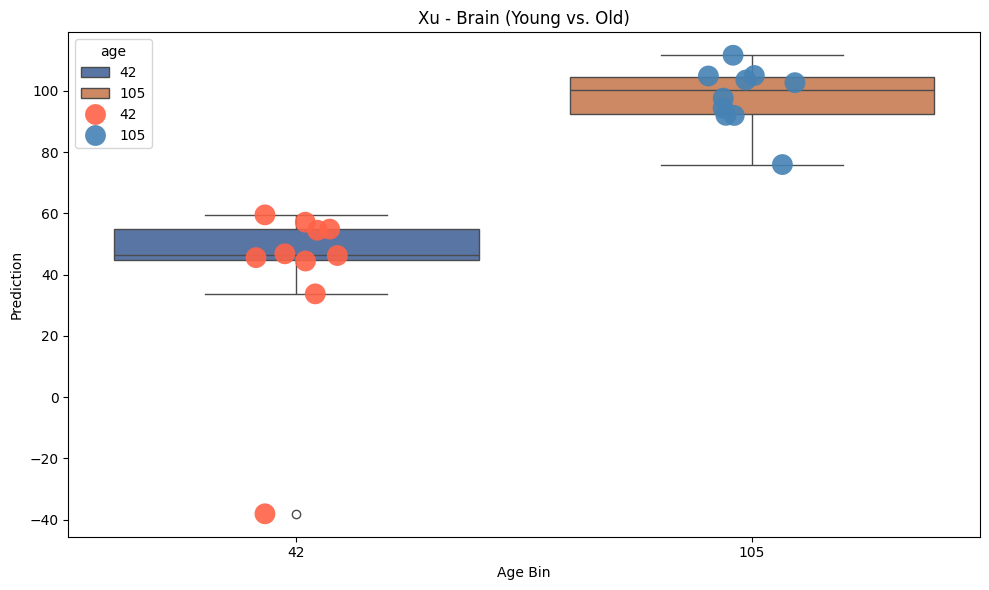

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Brain (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu[df_prediction_xu['age'] == 42]['y_pred']
group_16w = df_prediction_xu[df_prediction_xu['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 10
Group 16w size: 10
Welch’s t-test p-value: 0.0001
Mann-Whitney U test p-value: 0.0002


### Male

In [ ]:
brain_df_male = brain_df[brain_df["sex"] == "M"]

brain_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,M,Brain,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,M,Brain,152
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,M,Brain,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,M,Brain,162
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373,M,Brain,49


In [ ]:
brain_df_male_age = brain_df_male.iloc[:,:-3]

brain_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,1468.986639,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,1841.111908,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,1837.550333,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,1570.372948,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,2326.060124,77.974382,936.746297,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373


In [ ]:
brain_df_male_age["age"] = brain_df_male["age_days"].tolist()

In [ ]:
brain_atlas_plus_xu_male = pd.concat([brain_df_male_age, df_counts_brain_male_xu], axis=0)

brain_atlas_plus_xu_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A21_2,53.082851,503.745418,485.328919,309.830515,144.623685,546.536696,2395.769875,326.080367,486.953904,418.162863,...,102.915731,523.786902,215.039711,609.369457,19.499823,1015.074101,613.702751,159.790213,334.205294,162
A22_2,52.450281,430.841595,533.066122,344.673276,94.731630,475.263772,2237.165051,269.209096,439.404906,449.573838,...,63.689627,754.641799,261.180992,611.741544,21.408278,1192.976291,894.866020,181.435156,439.404906,152
A24_2,43.256835,536.384749,414.112096,325.868154,98.048825,484.476547,1956.939196,307.411904,321.254091,415.265612,...,73.824998,694.416384,223.205266,566.376154,23.647070,981.065008,760.166773,155.147847,410.651550,103
B21_2,40.582672,504.195584,454.790592,391.711005,112.043463,464.054028,1794.018758,178.651979,393.475469,470.670768,...,43.229368,715.049030,235.114826,775.040806,24.261380,1051.179420,1012.802328,187.474299,307.016734,162
B22_2,46.363146,593.237531,411.999777,362.475507,83.769776,404.623822,2161.681696,285.027979,385.130227,367.217193,...,77.974382,936.746297,190.194271,613.784834,23.708427,1295.006973,913.564724,285.027979,431.493373,49


In [ ]:
brain_atlas_plus_xu_male_data = brain_atlas_plus_xu_male.values

In [ ]:
X, y = brain_atlas_plus_xu_male_data[:,:-1], brain_atlas_plus_xu_male_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best Parameters

##### alpha = 0.01, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 15.270
Pearson correlation: 0.893
R-squared: 0.788
Average number of non-zero coefficients: 52.83


In [ ]:
# Create a DataFrame
df_prediction_male = pd.DataFrame({
    'y_pred': y_pred,
    'age': brain_atlas_plus_xu_male["age"].tolist(),
}, index=brain_atlas_plus_xu_male.index.tolist())

df_prediction_male.head(10)

,y_pred,age
A21_2,151.517781,162
A22_2,135.115955,152
A24_2,100.353705,103
B21_2,131.169939,162
B22_2,46.400309,49
B23_2,102.827026,78
B24_2,134.470248,133
C21_2,109.154156,102
C24_2,124.650460,133
D21_2,107.671171,102


In [ ]:
df_prediction_xu_brain_male = df_prediction_male.loc[df_counts_brain_male.index.tolist(), ]

df_prediction_xu_brain_male

,y_pred,age
brain_5,62.845873,42
brain_4,53.587603,42
brain_3,51.525702,42
brain_15,94.324991,105
brain_14,86.503368,105
brain_13,99.178240,105
brain_12,101.927698,105
brain_11,101.844723,105
brain_2,56.217628,42
brain_1,36.294783,42


In [ ]:
df_prediction_xu_brain_male["weeks"] = df_counts_brain_male["age"].tolist()

In [ ]:
df_prediction_xu_brain_male.to_csv("./df_prediction_xu_brain_male_only.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

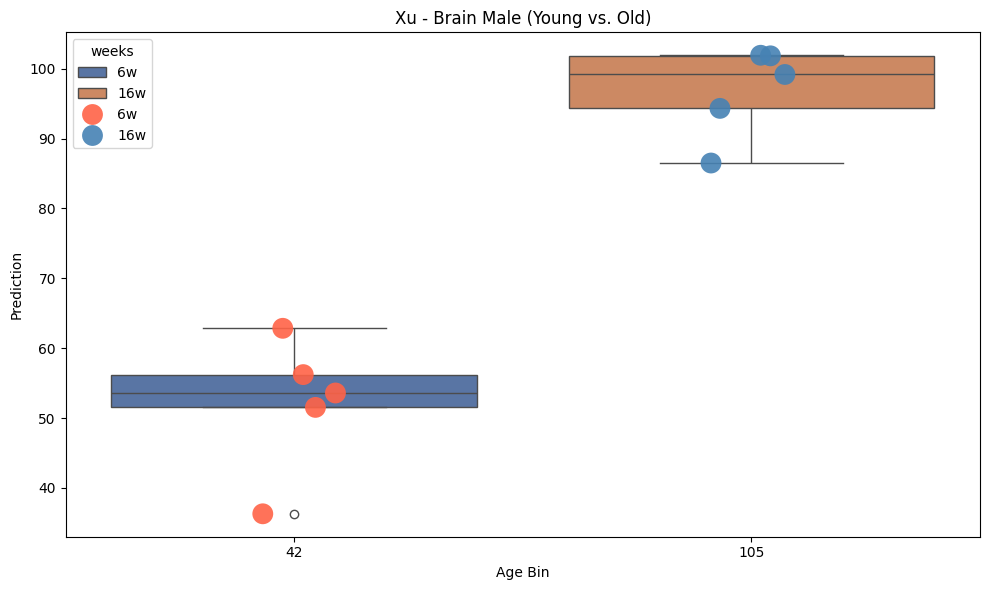

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='weeks', data=df_prediction_xu_brain_male, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='weeks',
    data=df_prediction_xu_brain_male,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Brain Male (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_brain_male[df_prediction_xu_brain_male['age'] == 42]['y_pred']
group_16w = df_prediction_xu_brain_male[df_prediction_xu_brain_male['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 5
Group 16w size: 5
Welch’s t-test p-value: 0.0001
Mann-Whitney U test p-value: 0.0079


### Female

In [ ]:
brain_df_female = brain_df[brain_df["sex"] == "F"]

brain_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,F,Brain,78
C22_2,26.304342,542.317178,356.507784,341.956446,93.464364,463.404152,2857.099272,389.528128,366.022120,348.672448,...,314.532770,457.807484,7.835336,1242.460408,826.627938,146.073048,434.301476,F,Brain,103
C23_2,37.729860,592.298911,484.499311,353.343132,107.200713,560.557917,2921.968033,204.819239,523.426944,464.137164,...,219.192519,630.627657,49.108706,1183.998934,798.914810,276.086752,457.549411,F,Brain,49
D23_2,45.887753,606.536140,567.463400,387.092727,105.859866,459.786197,1926.831288,239.888451,454.788521,333.026959,...,175.827330,689.679296,36.346735,1182.177555,884.134328,265.785499,567.009066,F,Brain,75
E21_2,116.364825,539.509645,537.586259,388.043033,110.113822,399.102500,2589.357786,264.946358,389.004726,373.617642,...,195.223633,557.300961,47.122946,1332.425334,890.046660,320.243693,427.953283,F,Brain,102


In [ ]:
brain_df_female_age = brain_df_female.iloc[:,:-3]

brain_df_female_age["age"] = brain_df_female["age_days"].tolist()

In [ ]:
brain_atlas_plus_xu_female = pd.concat([brain_df_female_age, df_counts_brain_female_xu], axis=0)

brain_atlas_plus_xu_female.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A23_2,17.414194,584.876719,587.879166,315.256959,104.485163,422.744569,3009.653097,232.389415,351.286325,369.301009,...,65.453349,807.057814,210.771795,505.011623,31.225451,1231.003362,736.800549,254.007035,441.960231,78
C22_2,26.304342,542.317178,356.507784,341.956446,93.464364,463.404152,2857.099272,389.528128,366.022120,348.672448,...,65.481022,805.360598,314.532770,457.807484,7.835336,1242.460408,826.627938,146.073048,434.301476,103
C23_2,37.729860,592.298911,484.499311,353.343132,107.200713,560.557917,2921.968033,204.819239,523.426944,464.137164,...,75.459720,913.302162,219.192519,630.627657,49.108706,1183.998934,798.914810,276.086752,457.549411,49


In [ ]:
brain_atlas_plus_xu_female.tail(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
brain_20,46.208095,101.657808,184.832378,50.828904,18.483238,83.174570,383.527185,36.966476,129.382665,9.241619,...,9.241619,688.500610,27.724857,101.657808,9.241619,277.248568,147.865903,503.668231,434.356089,105
brain_19,21.822551,94.564386,98.201478,58.193468,7.274184,94.564386,294.604433,29.096734,109.112753,43.645101,...,0.000000,574.660498,80.016019,72.741835,0.000000,320.064075,167.306221,509.192847,429.176828,105
brain_18,14.684980,91.781128,113.808599,73.424902,22.027471,124.822334,367.124512,66.082412,66.082412,29.369961,...,22.027471,653.481632,51.397432,117.479844,0.000000,256.987159,198.247237,565.371749,477.261866,105
brain_17,16.140655,107.940629,197.723022,74.650529,4.035164,132.151612,396.454835,59.518665,70.615365,34.298892,...,23.202191,581.063575,54.474710,108.949420,4.035164,399.481208,163.424131,508.430628,447.903173,105
brain_16,18.630969,116.961083,195.625174,43.472261,12.420646,144.907536,404.706048,69.348607,95.224952,55.892907,...,6.210323,666.574667,78.664091,94.189899,4.140215,369.514217,133.521944,515.456807,410.916371,105


In [ ]:
brain_atlas_plus_xu_female_data = brain_atlas_plus_xu_female.values

In [ ]:
X, y = brain_atlas_plus_xu_female_data[:,:-1], brain_atlas_plus_xu_female_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

#### Best Parameters

#### alpha = 0.1, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 12.090
Pearson correlation: 0.913
R-squared: 0.832
Average number of non-zero coefficients: 33.82


In [ ]:
brain_atlas_plus_xu_female_data.shape

(33, 25123)

In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': brain_atlas_plus_xu_female["age"].tolist(),
}, index=brain_atlas_plus_xu_female.index.tolist())

df_prediction.head(10)

,y_pred,age
A23_2,80.310765,78
C22_2,106.845358,103
C23_2,54.712607,49
D23_2,74.324479,75
E21_2,112.281185,102
E22_2,77.397430,77
F23_2,74.080562,47
F24_2,141.396752,147
G22_2,50.293964,47
G24_2,120.236387,147


In [ ]:
df_prediction_xu_brain_female = df_prediction.loc[df_counts_brain_female.index.tolist(), ]

df_prediction_xu_brain_female

,y_pred,age
brain_10,26.506920,42
brain_9,45.217645,42
brain_8,58.983832,42
brain_7,69.186658,42
brain_6,22.115970,42
brain_20,90.105529,105
brain_19,93.471117,105
brain_18,87.183771,105
brain_17,90.121293,105
brain_16,90.065621,105


In [ ]:
df_prediction_xu_brain_female.to_csv("./df_prediction_xu_brain_female_only.csv", sep="\t")

In [ ]:
# Set a seed for reproducibility
#np.random.seed(42)

# Create the box plot
#plt.figure(figsize=(10, 6))
#box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu_brain_female, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

#custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
#strip = sns.stripplot(
#    x='age',
#    y='y_pred',
#    hue='age',
#    data=df_prediction_xu_brain_female,
#    palette=custom_palette,  # Custom color palette
#    dodge=False, df_prediction_xu_brain_female = df_prediction.loc[df_counts_brain_female.index.tolist(), ]

#df_prediction_xu_brain_female
#    alpha=0.9,
#    jitter=True,
#    size=15
#)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
#plt.title('Xu - Female Brain (Young vs. Old)')
#plt.xlabel('Age Bin')
#plt.ylabel('Prediction')

# Remove the grid
#plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

#plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
#plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_brain_female[df_prediction_xu_brain_female['age'] == 42]['y_pred']
group_16w = df_prediction_xu_brain_female[df_prediction_xu_brain_female['age'] == 105]['y_pred']

In [ ]:
group_16w

brain_20    90.105529
brain_19    93.471117
brain_18    87.183771
brain_17    90.121293
brain_16    90.065621
Name: y_pred, dtype: float64

In [ ]:
print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

Group 6w size: 5
Group 16w size: 5


In [ ]:
# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Welch’s t-test p-value: 0.0069
Mann-Whitney U test p-value: 0.0079


# Heart

In [ ]:
df_counts_heart = pd.read_csv("../../Data_from_Others/AlanXu_Aging/CountsNormDESeq2_AlanXuAging_Heart_250605.csv")

df_counts_heart.head(5)

,Unnamed: 0,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,...,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
0,nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,...,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
1,dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,...,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
2,f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,...,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701
3,LOC107382877,145.551707,143.324323,168.873455,124.258452,109.164441,141.460366,117.489848,164.962580,167.359346,...,107.022385,90.871571,82.734439,145.378380,112.585692,80.505839,79.724434,93.702909,133.607004,66.092230
4,fezf1,0.000000,0.000000,0.000000,0.000000,2.599153,0.000000,1.727792,2.088134,1.770998,...,0.000000,1.622707,3.597150,2.202703,8.830250,1.829678,7.777994,4.259223,5.416500,5.507686


In [ ]:
df_counts_heart.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_counts_heart.head(3)

,sample,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,...,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
0,nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,...,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
1,dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,...,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
2,f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,...,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701


In [ ]:
df_counts_heart.set_index("sample", inplace=True)

df_counts_heart.head(3)

,Heart_20,Heart_19,Heart_18,Heart_17,Heart_16,Heart_15,Heart_14,Heart_13,Heart_12,Heart_11,Heart_10,Heart_9,Heart_8,Heart_7,Heart_6,Heart_5,Heart_4,Heart_3,Heart_2,Heart_1
sample,,,,,,,,,,,,,,,,,,,,
nadsyn1,151.327568,182.330309,164.475709,167.432999,191.037771,154.890147,159.820750,156.610045,192.153323,164.843222,180.069409,147.666303,178.958188,219.168922,175.501225,170.160069,187.644093,144.813586,196.799505,213.422826
dnaja3,316.517203,406.387952,365.892485,351.714601,456.151413,454.821935,520.065359,405.097982,390.505140,441.476674,361.837587,355.372752,464.032287,489.000007,459.173017,350.383367,475.429853,556.893424,473.041013,536.999368
f2r,128.224123,138.788743,169.753004,90.561245,62.379680,127.135265,158.956854,231.782866,68.183437,111.790231,47.565504,50.303905,50.360093,35.243244,33.113439,56.720023,52.501456,76.666016,43.332001,57.830701


In [ ]:
df_counts_heart = df_counts_heart.T

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_metadata_heart = df_counts_metadata[df_counts_metadata["tissue"] == "Heart"]

df_counts_metadata_heart.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
44,Heart_20,SRR24062706,16w,RNA-Seq,300,4686084900,Dario Valenzano laboratory,PRJNA952180,SAMN34067672,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8241_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062706.featureCounts,SRR24062706
45,Heart_19,SRR24062707,16w,RNA-Seq,300,5791702200,Dario Valenzano laboratory,PRJNA952180,SAMN34067671,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:33:00Z,1,GRZ-AD_8232_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062707.featureCounts,SRR24062707
46,Heart_18,SRR24062708,16w,RNA-Seq,300,6389682000,Dario Valenzano laboratory,PRJNA952180,SAMN34067670,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062708.featureCounts,SRR24062708
47,Heart_17,SRR24062709,16w,RNA-Seq,300,4797343200,Dario Valenzano laboratory,PRJNA952180,SAMN34067669,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8249_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062709.featureCounts,SRR24062709
48,Heart_16,SRR24062710,16w,RNA-Seq,300,3748359600,Dario Valenzano laboratory,PRJNA952180,SAMN34067668,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8225_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062710.featureCounts,SRR24062710


In [ ]:
df_counts_metadata_heart.set_index("Sample.Name", inplace=True)

df_counts_metadata_heart.head(5)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
Heart_20,SRR24062706,16w,RNA-Seq,300,4686084900,Dario Valenzano laboratory,PRJNA952180,SAMN34067672,Model organism or animal,1702634097,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8241_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062706.featureCounts,SRR24062706
Heart_19,SRR24062707,16w,RNA-Seq,300,5791702200,Dario Valenzano laboratory,PRJNA952180,SAMN34067671,Model organism or animal,2101107088,...,2023-06-20T00:00:00Z,2023-04-04T11:33:00Z,1,GRZ-AD_8232_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062707.featureCounts,SRR24062707
Heart_18,SRR24062708,16w,RNA-Seq,300,6389682000,Dario Valenzano laboratory,PRJNA952180,SAMN34067670,Model organism or animal,2325189392,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062708.featureCounts,SRR24062708
Heart_17,SRR24062709,16w,RNA-Seq,300,4797343200,Dario Valenzano laboratory,PRJNA952180,SAMN34067669,Model organism or animal,1735025366,...,2023-06-20T00:00:00Z,2023-04-04T11:23:00Z,1,GRZ-AD_8249_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062709.featureCounts,SRR24062709
Heart_16,SRR24062710,16w,RNA-Seq,300,3748359600,Dario Valenzano laboratory,PRJNA952180,SAMN34067668,Model organism or animal,1365565651,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8225_16w_Female_Heart,female,SRP430823,GRZ-AD,Heart,SRR24062710.featureCounts,SRR24062710


In [ ]:
df_counts_heart = df_counts_heart.loc[df_counts_metadata_heart.index.tolist(),]

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_heart["tissue"] = df_counts_metadata_heart["tissue"].tolist()
df_counts_heart["age"] = df_counts_metadata_heart["age"].tolist()
df_counts_heart["sex"] = df_counts_metadata_heart["sex"].tolist()

df_counts_heart.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex
Heart_20,151.327568,316.517203,128.224123,145.551707,0.0,91.258610,0.000000,4.620689,180.206875,548.706831,...,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336,Heart,16w,female
Heart_19,182.330309,406.387952,138.788743,143.324323,0.0,65.312349,1.814232,0.000000,270.320558,426.344504,...,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597,Heart,16w,female
Heart_18,164.475709,365.892485,169.753004,168.873455,0.0,84.436727,0.000000,3.518197,164.475709,498.704421,...,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686,Heart,16w,female


In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 105
}

df_counts_heart["new_age"] = df_counts_heart["age"].map(age_mapping)

df_counts_heart.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336,Heart,16w,female,105
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597,Heart,16w,female,105
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686,Heart,16w,female,105
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320,Heart,16w,female,105
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901,Heart,16w,female,105


In [ ]:
df_counts_heart_age = df_counts_heart.copy()

df_counts_heart_age = df_counts_heart_age.iloc[:,:-4]

df_counts_heart_age.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,5.775861,1157.482619,0.0,2.310345,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,18.142319,1129.359377,0.0,3.628464,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,7.036394,1081.845569,0.0,0.000000,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,21.060755,1025.658747,0.0,0.000000,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,7.797460,873.315526,0.0,2.599153,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901


In [ ]:
df_counts_heart_age["age"] = df_counts_heart["new_age"].tolist()

In [ ]:
df_counts_heart_male = df_counts_heart[df_counts_heart["sex"] == "male"]

df_counts_heart_male.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
Heart_15,154.890147,454.821935,127.135265,141.460366,0.000000,100.275702,1.790638,0.0,461.984486,415.427910,...,12.534463,12.534463,30.440838,2147.869731,184.435667,99.380384,Heart,16w,male,105
Heart_14,159.820750,520.065359,158.956854,117.489848,1.727792,61.336612,0.000000,0.0,238.435281,495.876272,...,3.455584,10.366751,39.739213,3201.598371,317.913708,82.934011,Heart,16w,male,105
Heart_13,156.610045,405.097982,231.782866,164.962580,2.088134,77.260955,0.000000,0.0,235.959134,491.755540,...,8.352536,2.088134,31.322009,2570.492864,139.904973,73.084687,Heart,16w,male,105


In [ ]:
df_counts_heart_male_xu = df_counts_heart_male.iloc[:,:-4]

df_counts_heart_male_xu["age"] = df_counts_heart_male["new_age"].tolist()

/tmp/ipykernel_440845/2551923067.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_heart_male_xu["age"] = df_counts_heart_male["new_age"].tolist()


In [ ]:
df_counts_heart_female = df_counts_heart[df_counts_heart["sex"] == "female"]

df_counts_heart_female.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
Heart_20,151.327568,316.517203,128.224123,145.551707,0.000000,91.258610,0.000000,4.620689,180.206875,548.706831,...,4.620689,4.620689,46.206891,2271.068693,227.568938,69.310336,Heart,16w,female,105
Heart_19,182.330309,406.387952,138.788743,143.324323,0.000000,65.312349,1.814232,0.000000,270.320558,426.344504,...,11.792508,5.442696,34.470407,1949.392209,137.881627,90.711597,Heart,16w,female,105
Heart_18,164.475709,365.892485,169.753004,168.873455,0.000000,84.436727,0.000000,3.518197,164.475709,498.704421,...,0.000000,14.072788,36.941068,2146.979703,219.007762,74.761686,Heart,16w,female,105
Heart_17,167.432999,351.714601,90.561245,124.258452,0.000000,94.773395,0.000000,0.000000,358.032827,498.086845,...,6.318226,6.318226,35.803283,1825.967420,174.804263,92.667320,Heart,16w,female,105
Heart_16,191.037771,456.151413,62.379680,109.164441,2.599153,64.978834,0.000000,0.000000,218.328882,488.640830,...,2.599153,7.797460,49.383914,2432.807538,210.531422,116.961901,Heart,16w,female,105


In [ ]:
df_counts_heart_female_xu = df_counts_heart_female.iloc[:,:-4]

df_counts_heart_female_xu["age"] = df_counts_heart_female["new_age"].tolist()

/tmp/ipykernel_440845/1700883121.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_heart_female_xu["age"] = df_counts_heart_female["new_age"].tolist()


#### Heart Atlas

In [ ]:
heart_df = combined_df.loc[combined_df.iloc[:,-2] == "Heart"]

heart_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [ ]:
heart_df_age = heart_df.iloc[:,:-3]

heart_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [ ]:
heart_df_age["age"] = heart_df["age_days"].tolist()

In [ ]:
heart_atlas_plus_xu = pd.concat([heart_df_age, df_counts_heart_age], axis=0)

heart_atlas_plus_xu.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,103


In [ ]:
heart_atlas_xu_data = heart_atlas_plus_xu.values

In [ ]:
X, y = heart_atlas_xu_data[:,:-1], heart_atlas_xu_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best parameters

##### alpha = 0.01, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    #model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    model = ElasticNet(alpha=0.01, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 12.963
Pearson correlation: 0.764
R-squared: 0.502
Average number of non-zero coefficients: 92.70


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': heart_atlas_plus_xu["age"].tolist(),
}, index=heart_atlas_plus_xu.index.tolist())

df_prediction.head(10)

,y_pred,age
A13_2,172.449855,162
A14_2,108.236458,103
A15_2,103.447993,103
B13_2,129.260000,134
B14_2,47.767864,47
B15_2,83.937925,75
B16_2,107.534923,103
C13_2,143.738076,162
C14_2,146.726180,152
C15_2,75.052527,75


In [ ]:
df_prediction_xu = df_prediction.loc[df_counts_heart_age.index.tolist(), ]

df_prediction_xu.head(5)

,y_pred,age
Heart_20,94.336326,105
Heart_19,99.361947,105
Heart_18,99.620548,105
Heart_17,92.655931,105
Heart_16,103.382587,105


In [ ]:
df_prediction_xu.to_csv("./Xu_heart_sex_combined.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

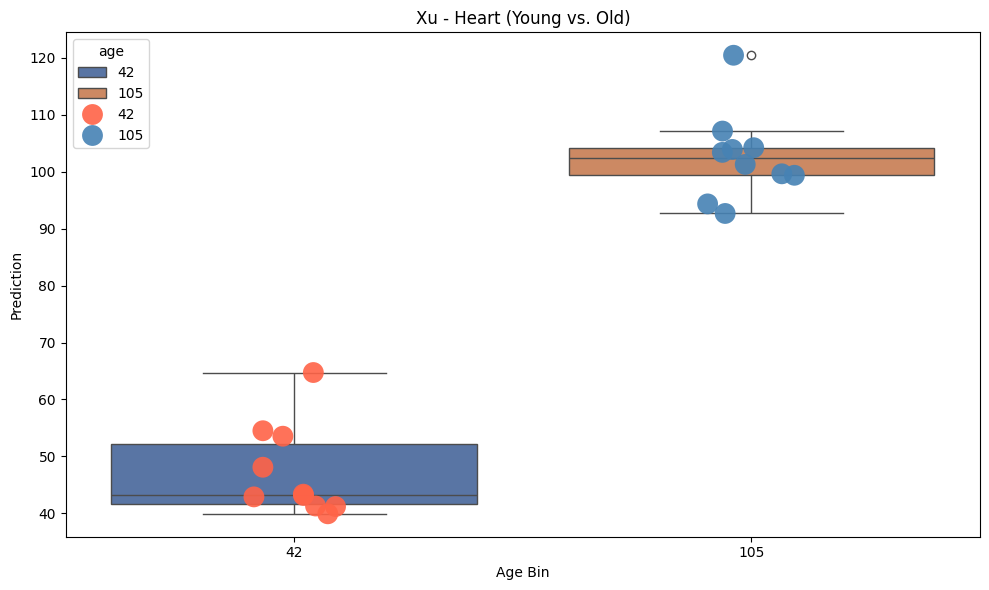

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Heart (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu[df_prediction_xu['age'] == 42]['y_pred']
group_16w = df_prediction_xu[df_prediction_xu['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 10
Group 16w size: 10
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0002


### Male

In [ ]:
heart_df_male = heart_df[heart_df["sex"] == "M"]

heart_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,M,Heart,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,M,Heart,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,M,Heart,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,M,Heart,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,M,Heart,47


In [ ]:
heart_df_male_age = heart_df_male.iloc[:,:-3]

heart_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,837.894212,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,948.993808,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,764.407581,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,766.967930,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,651.066933,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187


In [ ]:
heart_df_male_age["age"] = heart_df_male["age_days"].tolist()

In [ ]:
heart_atlas_plus_xu_male = pd.concat([heart_df_male_age, df_counts_heart_male_xu], axis=0)

heart_atlas_plus_xu_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_2,26.477799,505.640544,194.739939,536.388955,640.591905,766.147919,1105.234567,997.615127,667.923826,527.847730,...,68.329803,1483.610852,213.530635,1276.059075,9.395348,825.082374,3853.800902,227.196596,538.951323,162
A14_2,2.932010,680.226251,240.424796,600.084653,488.668284,815.098698,1014.475358,1355.565820,690.976954,632.336760,...,102.620340,1423.979380,98.710993,1270.537539,28.342760,699.772983,5555.181053,215.014045,434.914773,103
A15_2,0.837248,596.957947,225.219758,452.114013,365.040203,632.122370,1239.127294,843.108909,613.702910,489.790181,...,66.979854,1732.266467,151.541919,1415.786659,79.538576,1085.910879,6306.153230,280.478138,380.947918,103
B13_2,20.962146,585.707020,218.252932,487.061627,445.137335,694.216952,912.469884,1789.180813,537.617391,647.360391,...,67.818708,1583.258555,191.125449,1464.884084,53.021899,822.455963,4199.827601,228.117471,453.768807,134
B14_2,79.955588,662.489160,237.851078,465.623720,548.938787,626.878688,1090.486721,934.606918,580.517885,624.191105,...,81.971275,2270.335570,176.708569,1688.473894,112.878478,876.151993,4780.537904,313.775292,423.966187,47


In [ ]:
heart_atlas_plus_xu_male_data = heart_atlas_plus_xu_male.values

In [ ]:
X, y = heart_atlas_plus_xu_male_data[:,:-1], heart_atlas_plus_xu_male_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

#### Best parameters

##### alpha = 1.0, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=1.0, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 10.333
Pearson correlation: 0.959
R-squared: 0.910
Average number of non-zero coefficients: 34.14


In [ ]:
# Create a DataFrame
df_prediction_male = pd.DataFrame({
    'y_pred': y_pred,
    'age': heart_atlas_plus_xu_male["age"].tolist(),
}, index=heart_atlas_plus_xu_male.index.tolist())

df_prediction_male.head(10)

,y_pred,age
A13_2,170.928359,162
A14_2,111.789478,103
A15_2,99.728491,103
B13_2,115.740981,134
B14_2,57.206462,47
C13_2,147.779247,162
C14_2,150.361902,152
C16_2,115.263420,147
D13_2,95.804789,78
D15_2,100.814476,75


In [ ]:
df_prediction_xu_heart_male = df_prediction_male.loc[df_counts_heart_male.index.tolist(), ]

df_prediction_xu_heart_male

,y_pred,age
Heart_15,98.470357,105
Heart_14,94.203538,105
Heart_13,110.901354,105
Heart_12,83.026055,105
Heart_11,110.902852,105
Heart_5,48.717975,42
Heart_4,44.575931,42
Heart_3,48.833483,42
Heart_2,37.933281,42
Heart_1,53.105908,42


In [ ]:
df_prediction_xu_heart_male["weeks"] = df_counts_heart_male["age"].tolist()

In [ ]:
df_prediction_xu_heart_male.to_csv("./Xu_heart_sex_male.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

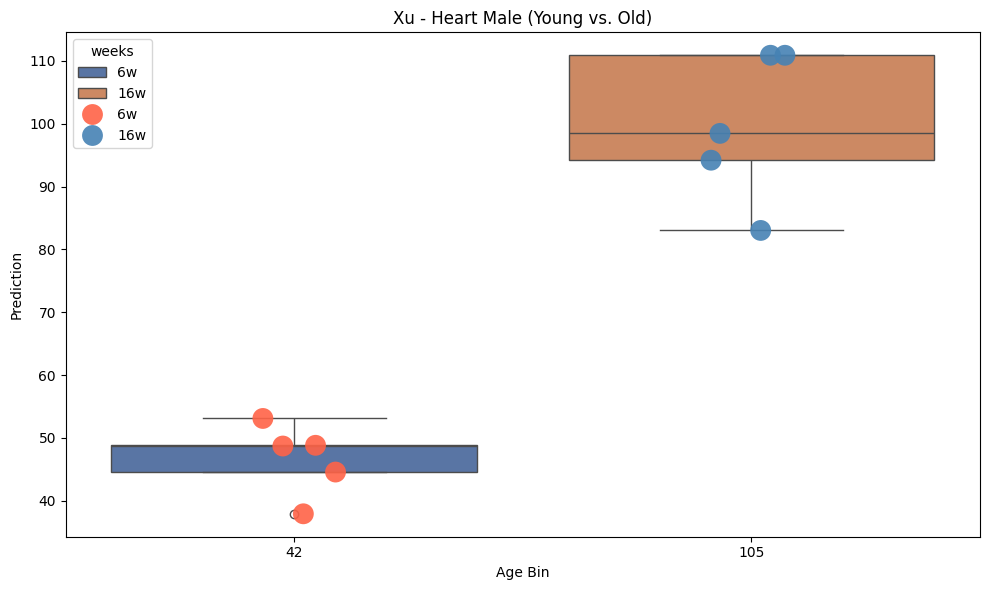

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='weeks', data=df_prediction_xu_heart_male, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='weeks',
    data=df_prediction_xu_heart_male,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Heart Male (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_heart_male[df_prediction_xu_heart_male['age'] == 42]['y_pred']
group_16w = df_prediction_xu_heart_male[df_prediction_xu_heart_male['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 5
Group 16w size: 5
Welch’s t-test p-value: 0.0001
Mann-Whitney U test p-value: 0.0079


### Female

In [ ]:
heart_df_female = heart_df[heart_df["sex"] == "F"]

heart_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
B15_2,1.775166,827.819273,272.783906,544.976091,801.783499,675.154961,985.217363,905.926596,734.327175,689.356293,...,155.622923,1545.578229,110.652040,766.871893,4251.523574,361.542227,383.435947,F,Heart,75
B16_2,0.755241,513.563623,179.747268,517.339826,587.577203,718.233831,1095.098901,1731.766745,589.842925,611.744903,...,124.614703,1042.232058,9.818128,783.939765,6263.965714,229.593149,460.696779,F,Heart,103
C15_2,0.701235,823.951607,310.647287,445.985721,725.077414,732.089768,1006.974049,774.163893,520.316674,619.190867,...,178.113794,1884.920782,164.790321,746.114476,5004.717120,399.002948,388.484417,F,Heart,75
D14_2,23.259273,634.753062,177.820893,513.954902,545.467466,843.336219,969.386473,1786.462222,642.256053,520.707594,...,101.290382,1246.246851,3.751496,776.559597,5473.432134,387.904649,558.222551,F,Heart,133
D16_2,2.694510,489.502624,433.816087,468.844715,573.930599,760.749949,1014.033875,1009.543026,689.794523,526.327592,...,135.623663,1711.013758,52.093857,787.695048,10794.206478,377.231380,522.734912,F,Heart,47


In [ ]:
heart_df_female_age = heart_df_female.iloc[:,:-3]

heart_df_female_age["age"] = heart_df_female["age_days"].tolist()

In [ ]:
heart_atlas_plus_xu_female = pd.concat([heart_df_female_age, df_counts_heart_female_xu], axis=0)

heart_atlas_plus_xu_female.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
B15_2,1.775166,827.819273,272.783906,544.976091,801.783499,675.154961,985.217363,905.926596,734.327175,689.356293,...,89.350043,1805.344248,155.622923,1545.578229,110.652040,766.871893,4251.523574,361.542227,383.435947,75
B16_2,0.755241,513.563623,179.747268,517.339826,587.577203,718.233831,1095.098901,1731.766745,589.842925,611.744903,...,129.146146,1262.762319,124.614703,1042.232058,9.818128,783.939765,6263.965714,229.593149,460.696779,103
C15_2,0.701235,823.951607,310.647287,445.985721,725.077414,732.089768,1006.974049,774.163893,520.316674,619.190867,...,63.111187,2020.960451,178.113794,1884.920782,164.790321,746.114476,5004.717120,399.002948,388.484417,75


In [ ]:
heart_atlas_plus_xu_female.tail(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
Heart_10,0.000000,112.968073,79.842097,84.938401,45.866736,193.659553,372.030195,151.190353,107.022385,79.842097,...,22.083984,1519.547987,59.456880,298.983170,15.288912,290.489330,1983.311654,828.149406,462.064899,42
Heart_9,24.340599,113.589464,76.267212,114.400817,43.813079,203.649682,402.431244,137.930063,136.307357,45.435786,...,7.302180,1665.708355,53.549319,265.312534,21.095186,282.350953,4425.932330,1268.956584,334.277566,42
Heart_8,3.597150,111.511635,62.950116,109.713060,50.360093,170.864602,312.952008,155.576716,133.094532,60.252254,...,5.395724,1762.603262,37.770070,269.786214,17.985748,235.613293,1769.797561,1314.758147,562.953899,42
Heart_7,6.608108,85.905407,79.297298,57.270271,85.905407,202.648652,314.986491,194.939192,85.905407,83.702704,...,28.635136,1463.695967,46.256757,209.256760,16.520271,360.141897,887.689202,1037.472988,558.385143,42
Heart_6,4.415125,168.878537,117.000817,88.302503,86.094941,207.510883,305.747417,114.793254,86.094941,55.189064,...,28.698314,1650.153028,57.396627,230.690290,17.660501,226.275164,750.571277,1423.877864,556.305770,42


In [ ]:
heart_atlas_plus_xu_female_data = heart_atlas_plus_xu_female.values

In [ ]:
X, y = heart_atlas_plus_xu_female_data[:,:-1], heart_atlas_plus_xu_female_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best parameters

### alpha = 0.0001, l1_ratio = 0.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.0001, l1_ratio=0.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 17.819
Pearson correlation: 0.813
R-squared: 0.654
Average number of non-zero coefficients: 25110.69


In [ ]:
heart_atlas_plus_xu_female_data.shape

(32, 25123)

In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': heart_atlas_plus_xu_female["age"].tolist(),
}, index=heart_atlas_plus_xu_female.index.tolist())

df_prediction.head(10)

,y_pred,age
B15_2,97.161788,75
B16_2,142.326646,103
C15_2,46.162118,75
D14_2,152.735460,133
D16_2,106.959253,47
E14_2,42.542905,47
E16_2,36.087729,49
F13_2,101.315158,78
F14_2,126.422861,147
F15_2,106.986131,102


In [ ]:
df_prediction_xu_heart_female = df_prediction.loc[df_counts_heart_female.index.tolist(), ]

df_prediction_xu_heart_female

,y_pred,age
Heart_20,74.842969,105
Heart_19,108.842547,105
Heart_18,98.902987,105
Heart_17,80.471715,105
Heart_16,84.625527,105
Heart_10,72.655623,42
Heart_9,45.482521,42
Heart_8,42.863722,42
Heart_7,72.289703,42
Heart_6,46.249193,42


In [ ]:
df_prediction_xu_heart_female.to_csv("./Xu_heart_sex_female.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

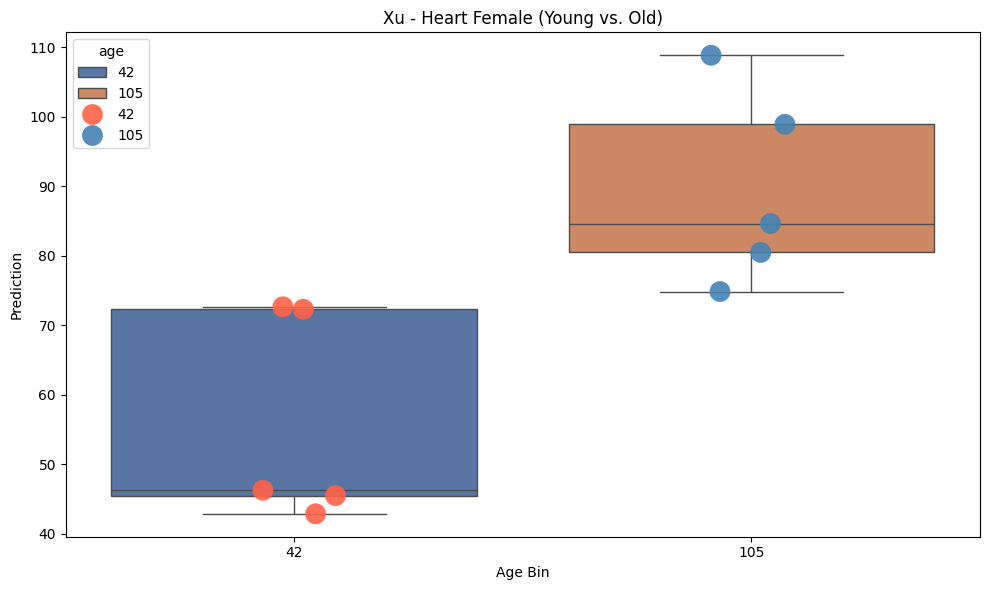

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu_heart_female, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu_heart_female,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Heart Female (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_heart_female[df_prediction_xu_heart_female['age'] == 42]['y_pred']
group_16w = df_prediction_xu_heart_female[df_prediction_xu_heart_female['age'] == 105]['y_pred']

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Welch’s t-test p-value: 0.0066
Mann-Whitney U test p-value: 0.0079


# Spleen

In [ ]:
df_counts_spleen = pd.read_csv("../../Data_from_Others/AlanXu_Aging/CountsNormDESeq2_AlanXuAging_Spleen_250605.csv")

df_counts_spleen.head(5)

,Unnamed: 0,spleen_19,spleen_18,spleen_17,spleen_16,spleen_15,spleen_14,spleen_13,spleen_12,spleen_11,spleen_10,spleen_9,spleen_8,spleen_7,spleen_6,spleen_5,spleen_4,spleen_3,spleen_2,spleen_1
0,nadsyn1,347.156333,329.989506,459.292642,451.777179,243.669068,356.359823,303.544801,436.162377,319.830313,458.824154,515.215488,465.387736,567.972380,124.998383,117.290543,342.633021,253.172467,356.410120,453.794995
1,dnaja3,456.929086,351.052666,393.852530,357.294933,471.850696,319.435794,242.835841,195.598592,421.527509,312.762486,302.636740,281.149570,429.816936,1039.759275,210.465273,248.152819,299.005414,479.890792,671.616592
2,f2r,517.304100,822.633414,616.833654,611.419596,655.634993,585.632288,681.596052,811.621743,389.102316,652.514628,222.003422,301.383820,271.796004,400.562999,350.775456,257.259345,307.735499,46.772982,275.302297
3,LOC107382877,34.303985,21.063160,29.084494,215.028561,115.639558,34.347935,29.434647,78.689089,53.796343,25.402029,12.566231,168.263758,16.253582,965.896594,10.961733,122.938094,283.727765,1609.926028,680.692492
4,fezf1,0.000000,0.000000,0.000000,0.000000,2.064992,22.326158,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_counts_spleen.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_counts_spleen.head(3)

,sample,spleen_19,spleen_18,spleen_17,spleen_16,spleen_15,spleen_14,spleen_13,spleen_12,spleen_11,spleen_10,spleen_9,spleen_8,spleen_7,spleen_6,spleen_5,spleen_4,spleen_3,spleen_2,spleen_1
0,nadsyn1,347.156333,329.989506,459.292642,451.777179,243.669068,356.359823,303.544801,436.162377,319.830313,458.824154,515.215488,465.387736,567.972380,124.998383,117.290543,342.633021,253.172467,356.410120,453.794995
1,dnaja3,456.929086,351.052666,393.852530,357.294933,471.850696,319.435794,242.835841,195.598592,421.527509,312.762486,302.636740,281.149570,429.816936,1039.759275,210.465273,248.152819,299.005414,479.890792,671.616592
2,f2r,517.304100,822.633414,616.833654,611.419596,655.634993,585.632288,681.596052,811.621743,389.102316,652.514628,222.003422,301.383820,271.796004,400.562999,350.775456,257.259345,307.735499,46.772982,275.302297


In [ ]:
df_counts_spleen.set_index("sample", inplace=True)

df_counts_spleen.head(3)

,spleen_19,spleen_18,spleen_17,spleen_16,spleen_15,spleen_14,spleen_13,spleen_12,spleen_11,spleen_10,spleen_9,spleen_8,spleen_7,spleen_6,spleen_5,spleen_4,spleen_3,spleen_2,spleen_1
sample,,,,,,,,,,,,,,,,,,,
nadsyn1,347.156333,329.989506,459.292642,451.777179,243.669068,356.359823,303.544801,436.162377,319.830313,458.824154,515.215488,465.387736,567.972380,124.998383,117.290543,342.633021,253.172467,356.410120,453.794995
dnaja3,456.929086,351.052666,393.852530,357.294933,471.850696,319.435794,242.835841,195.598592,421.527509,312.762486,302.636740,281.149570,429.816936,1039.759275,210.465273,248.152819,299.005414,479.890792,671.616592
f2r,517.304100,822.633414,616.833654,611.419596,655.634993,585.632288,681.596052,811.621743,389.102316,652.514628,222.003422,301.383820,271.796004,400.562999,350.775456,257.259345,307.735499,46.772982,275.302297


In [ ]:
df_counts_spleen = df_counts_spleen.T

df_counts_spleen.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
spleen_19,347.156333,456.929086,517.304100,34.303985,0.000000,194.160558,0.000000,0.0,620.216057,879.554186,...,164.659130,1030.491722,0.0,304.619391,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464
spleen_18,329.989506,351.052666,822.633414,21.063160,0.000000,201.270195,0.000000,0.0,379.136879,812.101834,...,73.721060,432.964955,0.0,186.057913,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213
spleen_17,459.292642,393.852530,616.833654,29.084494,0.000000,168.447697,0.000000,0.0,433.237783,611.986238,...,225.404832,750.743514,0.0,206.621096,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180
spleen_16,451.777179,357.294933,611.419596,215.028561,0.000000,198.738519,0.000000,0.0,412.681077,759.115981,...,188.964493,741.739936,0.0,390.961020,0.0,0.000000,17.376045,1238.043232,184.620482,43.440113
spleen_15,243.669068,471.850696,655.634993,115.639558,2.064992,208.564203,16.519937,0.0,405.770949,615.367647,...,142.484455,556.515372,0.0,356.211138,0.0,0.000000,28.909889,1538.419118,88.794661,64.014755


In [ ]:
df_counts_metadata_spleen = df_counts_metadata[df_counts_metadata["tissue"] == "Spleen"]

df_counts_metadata_spleen.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
2,spleen_19,SRR24062664,16w,RNA-Seq,300,7202080500,Dario Valenzano laboratory,PRJNA952180,SAMN34067710,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8241_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062664.featureCounts,SRR24062664
3,spleen_18,SRR24062665,16w,RNA-Seq,300,4519062600,Dario Valenzano laboratory,PRJNA952180,SAMN34067709,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8232_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062665.featureCounts,SRR24062665
4,spleen_17,SRR24062666,16w,RNA-Seq,300,8545333200,Dario Valenzano laboratory,PRJNA952180,SAMN34067708,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8273_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062666.featureCounts,SRR24062666
5,spleen_16,SRR24062667,16w,RNA-Seq,300,4841396400,Dario Valenzano laboratory,PRJNA952180,SAMN34067707,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:27:00Z,1,GRZ-AD_8249_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062667.featureCounts,SRR24062667
6,spleen_15,SRR24062668,16w,RNA-Seq,300,4942003800,Dario Valenzano laboratory,PRJNA952180,SAMN34067706,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8225_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062668.featureCounts,SRR24062668


In [ ]:
df_counts_metadata_spleen.set_index("Sample.Name", inplace=True)

df_counts_metadata_spleen.head(5)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
spleen_19,SRR24062664,16w,RNA-Seq,300,7202080500,Dario Valenzano laboratory,PRJNA952180,SAMN34067710,Model organism or animal,2637021082,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8241_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062664.featureCounts,SRR24062664
spleen_18,SRR24062665,16w,RNA-Seq,300,4519062600,Dario Valenzano laboratory,PRJNA952180,SAMN34067709,Model organism or animal,1749414179,...,2023-06-20T00:00:00Z,2023-04-04T11:26:00Z,1,GRZ-AD_8232_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062665.featureCounts,SRR24062665
spleen_17,SRR24062666,16w,RNA-Seq,300,8545333200,Dario Valenzano laboratory,PRJNA952180,SAMN34067708,Model organism or animal,3232351663,...,2023-06-20T00:00:00Z,2023-04-04T11:34:00Z,1,GRZ-AD_8273_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062666.featureCounts,SRR24062666
spleen_16,SRR24062667,16w,RNA-Seq,300,4841396400,Dario Valenzano laboratory,PRJNA952180,SAMN34067707,Model organism or animal,1850434347,...,2023-06-20T00:00:00Z,2023-04-04T11:27:00Z,1,GRZ-AD_8249_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062667.featureCounts,SRR24062667
spleen_15,SRR24062668,16w,RNA-Seq,300,4942003800,Dario Valenzano laboratory,PRJNA952180,SAMN34067706,Model organism or animal,1899399880,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8225_16w_Female_Spleen,female,SRP430823,GRZ-AD,Spleen,SRR24062668.featureCounts,SRR24062668


In [ ]:
df_counts_spleen = df_counts_spleen.loc[df_counts_metadata_spleen.index.tolist(),]

df_counts_spleen.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
spleen_19,347.156333,456.929086,517.304100,34.303985,0.000000,194.160558,0.000000,0.0,620.216057,879.554186,...,164.659130,1030.491722,0.0,304.619391,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464
spleen_18,329.989506,351.052666,822.633414,21.063160,0.000000,201.270195,0.000000,0.0,379.136879,812.101834,...,73.721060,432.964955,0.0,186.057913,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213
spleen_17,459.292642,393.852530,616.833654,29.084494,0.000000,168.447697,0.000000,0.0,433.237783,611.986238,...,225.404832,750.743514,0.0,206.621096,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180
spleen_16,451.777179,357.294933,611.419596,215.028561,0.000000,198.738519,0.000000,0.0,412.681077,759.115981,...,188.964493,741.739936,0.0,390.961020,0.0,0.000000,17.376045,1238.043232,184.620482,43.440113
spleen_15,243.669068,471.850696,655.634993,115.639558,2.064992,208.564203,16.519937,0.0,405.770949,615.367647,...,142.484455,556.515372,0.0,356.211138,0.0,0.000000,28.909889,1538.419118,88.794661,64.014755


In [ ]:
df_counts_spleen["tissue"] = df_counts_metadata_spleen["tissue"].tolist()
df_counts_spleen["age"] = df_counts_metadata_spleen["age"].tolist()
df_counts_spleen["sex"] = df_counts_metadata_spleen["sex"].tolist()

df_counts_spleen.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex
spleen_19,347.156333,456.929086,517.304100,34.303985,0.0,194.160558,0.0,0.0,620.216057,879.554186,...,304.619391,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464,Spleen,16w,female
spleen_18,329.989506,351.052666,822.633414,21.063160,0.0,201.270195,0.0,0.0,379.136879,812.101834,...,186.057913,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213,Spleen,16w,female
spleen_17,459.292642,393.852530,616.833654,29.084494,0.0,168.447697,0.0,0.0,433.237783,611.986238,...,206.621096,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180,Spleen,16w,female


In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 105
}

df_counts_spleen["new_age"] = df_counts_spleen["age"].map(age_mapping)

df_counts_spleen.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
spleen_19,347.156333,456.929086,517.304100,34.303985,0.000000,194.160558,0.000000,0.0,620.216057,879.554186,...,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464,Spleen,16w,female,105
spleen_18,329.989506,351.052666,822.633414,21.063160,0.000000,201.270195,0.000000,0.0,379.136879,812.101834,...,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213,Spleen,16w,female,105
spleen_17,459.292642,393.852530,616.833654,29.084494,0.000000,168.447697,0.000000,0.0,433.237783,611.986238,...,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180,Spleen,16w,female,105
spleen_16,451.777179,357.294933,611.419596,215.028561,0.000000,198.738519,0.000000,0.0,412.681077,759.115981,...,0.0,0.000000,17.376045,1238.043232,184.620482,43.440113,Spleen,16w,female,105
spleen_15,243.669068,471.850696,655.634993,115.639558,2.064992,208.564203,16.519937,0.0,405.770949,615.367647,...,0.0,0.000000,28.909889,1538.419118,88.794661,64.014755,Spleen,16w,female,105


In [ ]:
df_counts_spleen_age = df_counts_spleen.copy()

df_counts_spleen_age = df_counts_spleen_age.iloc[:,:-4]

df_counts_spleen_age.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
spleen_19,347.156333,456.929086,517.304100,34.303985,0.000000,194.160558,0.000000,0.0,620.216057,879.554186,...,164.659130,1030.491722,0.0,304.619391,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464
spleen_18,329.989506,351.052666,822.633414,21.063160,0.000000,201.270195,0.000000,0.0,379.136879,812.101834,...,73.721060,432.964955,0.0,186.057913,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213
spleen_17,459.292642,393.852530,616.833654,29.084494,0.000000,168.447697,0.000000,0.0,433.237783,611.986238,...,225.404832,750.743514,0.0,206.621096,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180
spleen_16,451.777179,357.294933,611.419596,215.028561,0.000000,198.738519,0.000000,0.0,412.681077,759.115981,...,188.964493,741.739936,0.0,390.961020,0.0,0.000000,17.376045,1238.043232,184.620482,43.440113
spleen_15,243.669068,471.850696,655.634993,115.639558,2.064992,208.564203,16.519937,0.0,405.770949,615.367647,...,142.484455,556.515372,0.0,356.211138,0.0,0.000000,28.909889,1538.419118,88.794661,64.014755


In [ ]:
df_counts_spleen_age["age"] = df_counts_spleen["new_age"].tolist()

In [ ]:
df_counts_spleen_male = df_counts_spleen[df_counts_spleen["sex"] == "male"]

df_counts_spleen_male.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
spleen_14,356.359823,319.435794,585.632288,34.347935,22.326158,326.305381,0.000000,0.0,392.425155,1028.720647,...,0.0,0.000000,38.641427,1389.373962,161.435294,24.043554,Spleen,16w,male,105
spleen_13,303.544801,242.835841,681.596052,29.434647,0.000000,266.751491,0.000000,0.0,479.232852,1361.352439,...,0.0,0.000000,60.708960,3614.022793,122.337753,18.396655,Spleen,16w,male,105
spleen_12,436.162377,195.598592,811.621743,78.689089,0.000000,256.301603,20.983757,0.0,495.366548,904.549809,...,0.0,4.496519,25.480276,1601.510309,254.802763,54.707652,Spleen,16w,male,105


In [ ]:
df_counts_spleen_male_xu = df_counts_spleen_male.iloc[:,:-4]

df_counts_spleen_male_xu["age"] = df_counts_spleen_male["new_age"].tolist()

/tmp/ipykernel_440845/1556967547.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_spleen_male_xu["age"] = df_counts_spleen_male["new_age"].tolist()


In [ ]:
df_counts_spleen_female = df_counts_spleen[df_counts_spleen["sex"] == "female"]

df_counts_spleen_female.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
spleen_19,347.156333,456.929086,517.304100,34.303985,0.000000,194.160558,0.000000,0.0,620.216057,879.554186,...,0.0,17.838072,50.769898,1918.964945,142.704579,38.420464,Spleen,16w,female,105
spleen_18,329.989506,351.052666,822.633414,21.063160,0.000000,201.270195,0.000000,0.0,379.136879,812.101834,...,0.0,0.000000,0.000000,1401.870313,201.270195,28.084213,Spleen,16w,female,105
spleen_17,459.292642,393.852530,616.833654,29.084494,0.000000,168.447697,0.000000,0.0,433.237783,611.986238,...,0.0,9.694831,43.626742,1442.712112,266.607866,39.991180,Spleen,16w,female,105
spleen_16,451.777179,357.294933,611.419596,215.028561,0.000000,198.738519,0.000000,0.0,412.681077,759.115981,...,0.0,0.000000,17.376045,1238.043232,184.620482,43.440113,Spleen,16w,female,105
spleen_15,243.669068,471.850696,655.634993,115.639558,2.064992,208.564203,16.519937,0.0,405.770949,615.367647,...,0.0,0.000000,28.909889,1538.419118,88.794661,64.014755,Spleen,16w,female,105


In [ ]:
df_counts_spleen_female_xu = df_counts_spleen_female.iloc[:,:-4]

df_counts_spleen_female_xu["age"] = df_counts_spleen_female["new_age"].tolist()

/tmp/ipykernel_440845/1241026563.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_spleen_female_xu["age"] = df_counts_spleen_female["new_age"].tolist()


### Spleen Atlas

In [ ]:
spleen_df = combined_df.loc[combined_df.iloc[:,-2] == "Spleen"]

spleen_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,F,Spleen,78
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,M,Spleen,152
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,F,Spleen,155
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,M,Spleen,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,M,Spleen,102


In [ ]:
spleen_df_age = spleen_df.iloc[:,:-3]

spleen_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,503.101713,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,955.132396,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,1167.120293,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,611.783739,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,1406.295632,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715


In [ ]:
spleen_df_age["age"] = spleen_df["age_days"].tolist()

In [ ]:
spleen_atlas_plus_xu = pd.concat([spleen_df_age, df_counts_spleen_age], axis=0)

spleen_atlas_plus_xu.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,78
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,152
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,155


In [ ]:
spleen_atlas_xu_data = spleen_atlas_plus_xu.values

In [ ]:
X, y = spleen_atlas_xu_data[:,:-1], spleen_atlas_xu_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.096e+01, tolerance: 1.184e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.160e+01, tolerance: 1.181e+01 Linear regression models with null weight for the l1 regularization term are more efficiently fitt

Best parameters found:  {'alpha': 0.1, 'l1_ratio': 0.8}
Mean MAE: 19.010
Pearson correlation: 0.590
R-squared: 0.101


#### Best parameters

##### alpha = 0.001, l1_ratio = 0.9 yields some negative numbers

##### alpha = 0.1, l1_ratio = 0.8 yields no negative values but one sample is super old!

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=100000, random_state=seed, positive=True)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 19.010
Pearson correlation: 0.590
R-squared: 0.101
Average number of non-zero coefficients: 198.08


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': spleen_atlas_plus_xu["age"].tolist(),
}, index=spleen_atlas_plus_xu.index.tolist())

df_prediction.head(10)

,y_pred,age
A17_2,74.261866,78
A18_2,119.243487,152
A19_2,156.884836,155
A20_2,60.841179,47
B17_2,83.536596,102
B18_2,92.668616,75
B19_2,89.616202,78
B20_2,138.239537,161
C17_2,151.194306,162
C18_2,153.391507,75


In [ ]:
df_prediction_xu = df_prediction.loc[df_counts_spleen_age.index.tolist(), ]

df_prediction_xu.head(5)

,y_pred,age
spleen_19,95.703921,105
spleen_18,99.247190,105
spleen_17,99.265277,105
spleen_16,112.067553,105
spleen_15,129.720401,105


In [ ]:
df_prediction_xu

,y_pred,age
spleen_19,95.703921,105
spleen_18,99.247190,105
spleen_17,99.265277,105
spleen_16,112.067553,105
spleen_15,129.720401,105
spleen_14,111.541905,105
spleen_13,111.151242,105
spleen_12,106.135102,105
spleen_11,102.597138,105
spleen_10,106.108631,105


In [ ]:
df_prediction_xu.to_csv("./Xu_spleen_sex_combined_no_negative.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

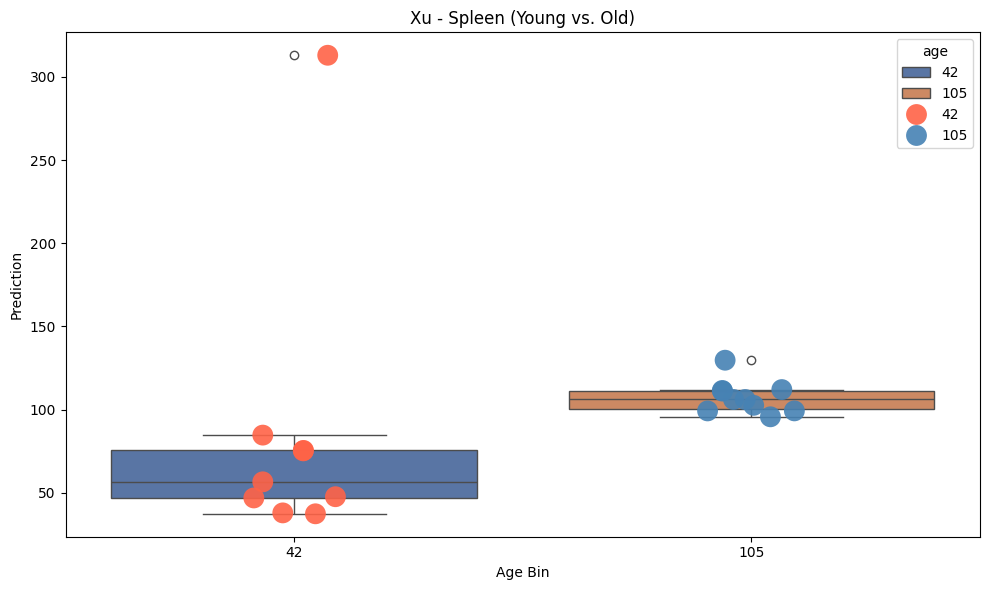

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Spleen (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu[df_prediction_xu['age'] == 42]['y_pred']
group_16w = df_prediction_xu[df_prediction_xu['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 9
Group 16w size: 10
Welch’s t-test p-value: 0.4858
Mann-Whitney U test p-value: 0.0048


#### Male

In [ ]:
spleen_df_male = spleen_df[spleen_df["sex"] == "M"]

spleen_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,M,Spleen,152
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,M,Spleen,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,M,Spleen,102
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909,M,Spleen,78
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295,M,Spleen,161


In [ ]:
spleen_df_male_age = spleen_df_male.iloc[:,:-3]

spleen_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,955.132396,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,611.783739,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,1406.295632,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,761.360012,116.583252,1200.093719,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,887.648075,68.522966,1338.954506,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295


In [ ]:
spleen_df_male_age["age"] = spleen_df_male["age_days"].tolist()

In [ ]:
spleen_atlas_plus_xu_male = pd.concat([spleen_df_male_age, df_counts_spleen_male_xu], axis=0)

spleen_atlas_plus_xu_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A18_2,127.857810,563.956610,89.154905,447.847896,407.071622,689.741050,2365.715045,958.588013,563.956610,796.865161,...,143.062522,1398.833553,174.854194,1036.684945,17.278082,632.377817,4201.338522,395.322526,494.153157,152
A20_2,263.871273,759.985412,123.802618,364.178503,591.903026,819.627549,1278.691271,659.678182,647.930488,984.095261,...,99.403562,1347.370095,136.453980,1659.135811,187.963098,445.508690,2697.451196,178.022742,395.806909,47
B17_2,116.199639,712.597787,111.299654,216.299328,492.798469,678.997891,1679.294784,643.298002,613.198096,769.997609,...,88.899724,1574.995108,265.999174,1023.396821,80.499750,521.498380,10473.367471,505.398430,413.698715,102
B19_2,61.384651,568.164909,193.195103,390.672856,743.277712,683.796461,1412.798672,992.623116,659.528110,827.503163,...,116.583252,1200.093719,165.595803,1333.807571,66.619001,568.164909,2992.144847,212.704953,549.130909,78
B20_2,0.787620,631.671479,191.391732,389.872047,827.001312,581.263779,1487.814742,858.506124,671.052493,867.957568,...,68.522966,1338.954506,207.144138,1233.413386,32.292432,562.360892,3421.422572,289.844269,515.891295,161


In [ ]:
spleen_atlas_plus_xu_male_data = spleen_atlas_plus_xu_male.values

In [ ]:
X, y = spleen_atlas_plus_xu_male_data[:,:-1], spleen_atlas_plus_xu_male_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

#### Best parameters

##### alpha = 0.01, l1_ratio = 0.9

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=0.9, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 13.805
Pearson correlation: 0.907
R-squared: 0.814
Average number of non-zero coefficients: 129.36


In [ ]:
# Create a DataFrame
df_prediction_male = pd.DataFrame({
    'y_pred': y_pred,
    'age': spleen_atlas_plus_xu_male["age"].tolist(),
}, index=spleen_atlas_plus_xu_male.index.tolist())

df_prediction_male.head(10)

,y_pred,age
A18_2,132.412132,152
A20_2,50.135107,47
B17_2,115.018242,102
B19_2,110.738665,78
B20_2,139.489236,161
C17_2,154.851205,162
D18_2,122.780552,133
D19_2,114.958459,134
E17_2,104.254767,162
E18_2,37.084417,49


In [ ]:
df_prediction_xu_spleen_male = df_prediction_male.loc[df_counts_spleen_male.index.tolist(), ]

df_prediction_xu_spleen_male

,y_pred,age
spleen_14,106.888033,105
spleen_13,113.351796,105
spleen_12,97.487529,105
spleen_11,98.231887,105
spleen_10,94.732932,105
spleen_5,38.632551,42
spleen_4,47.989574,42
spleen_3,38.005128,42
spleen_2,77.972699,42
spleen_1,52.352636,42


In [ ]:
df_prediction_xu_spleen_male["weeks"] = df_counts_spleen_male["age"].tolist()

In [ ]:
df_prediction_xu_spleen_male.to_csv("./Xu_spleen_sex_male.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

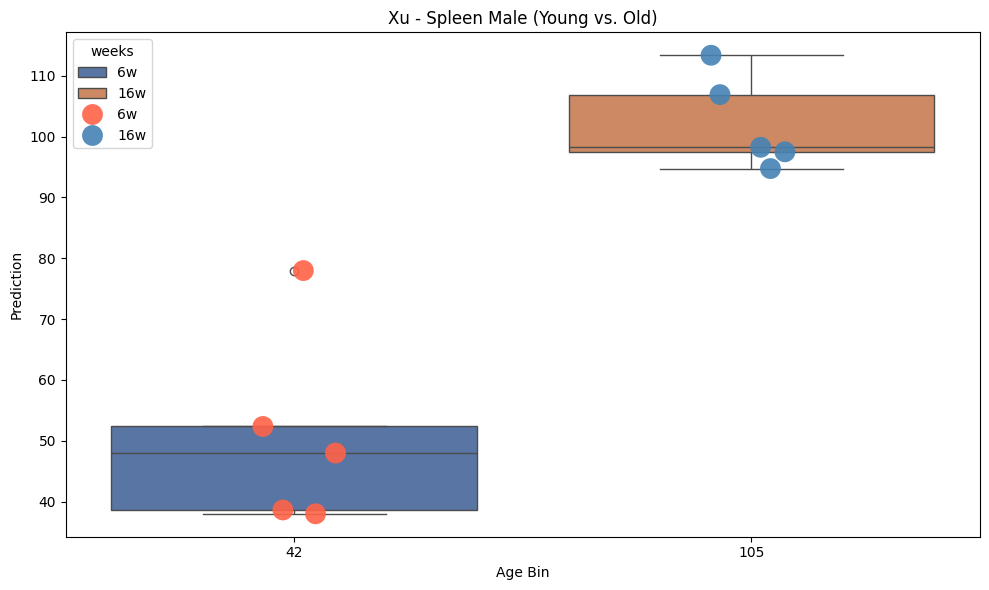

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='weeks', data=df_prediction_xu_spleen_male, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='weeks',
    data=df_prediction_xu_spleen_male,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Spleen Male (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_spleen_male[df_prediction_xu_spleen_male['age'] == 42]['y_pred']
group_16w = df_prediction_xu_spleen_male[df_prediction_xu_spleen_male['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 5
Group 16w size: 5
Welch’s t-test p-value: 0.0009
Mann-Whitney U test p-value: 0.0079


#### Female

In [ ]:
spleen_df_female = spleen_df[spleen_df["sex"] == "F"]

spleen_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,F,Spleen,78
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,F,Spleen,155
B18_2,30.277472,820.712755,248.661792,376.213696,1014.617417,733.745548,1430.771609,709.910091,776.262850,963.725496,...,188.106848,1454.607066,75.371580,700.891270,3133.396266,237.066165,581.713986,F,Spleen,75
C18_2,4.621708,538.098877,171.663445,386.902996,921.700653,592.238886,1420.184888,1066.954337,457.549106,682.692317,...,198.073206,1071.576045,34.332689,839.830394,2272.559919,197.412962,644.398164,F,Spleen,75
C19_2,19.181350,903.542557,150.926941,559.792568,522.944184,732.424721,1566.308690,561.811657,773.816056,1001.468399,...,186.765780,1288.683882,111.049923,606.736399,3812.545774,393.722455,490.133979,F,Spleen,155


In [ ]:
spleen_df_female_age = spleen_df_female.iloc[:,:-3]

spleen_df_female_age["age"] = spleen_df_female["age_days"].tolist()

In [ ]:
spleen_atlas_plus_xu_female = pd.concat([spleen_df_female_age, df_counts_spleen_female_xu], axis=0)

spleen_atlas_plus_xu_female.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A17_2,500.972933,610.959908,255.453620,361.183035,1160.894784,772.037607,1334.035571,796.873376,806.807683,725.204443,...,137.661117,1245.336398,172.431194,1597.294718,83.022427,485.361878,1625.678454,108.567789,412.273759,78
A19_2,13.175394,714.765109,185.553462,409.535155,658.769686,637.908646,1812.714586,883.849329,396.359761,586.305020,...,96.619554,1352.673755,223.981693,1208.842374,45.015929,540.191142,3514.536274,254.724279,603.872212,155
B18_2,30.277472,820.712755,248.661792,376.213696,1014.617417,733.745548,1430.771609,709.910091,776.262850,963.725496,...,100.495439,1523.536630,188.106848,1454.607066,75.371580,700.891270,3133.396266,237.066165,581.713986,75


In [ ]:
spleen_atlas_plus_xu_female_data = spleen_atlas_plus_xu_female.values

In [ ]:
X, y = spleen_atlas_plus_xu_female_data[:,:-1], spleen_atlas_plus_xu_female_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Best parameters

### alpha = 0.1, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.1, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 13.269
Pearson correlation: 0.896
R-squared: 0.801
Average number of non-zero coefficients: 32.16


In [ ]:
spleen_atlas_plus_xu_female_data.shape

(32, 25123)

In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': spleen_atlas_plus_xu_female["age"].tolist(),
}, index=spleen_atlas_plus_xu_female.index.tolist())

df_prediction.head(10)

,y_pred,age
A17_2,79.007863,78
A19_2,132.360311,155
B18_2,73.002032,75
C18_2,126.653365,75
C19_2,136.928608,155
C20_2,56.966652,47
D17_2,96.497243,102
D20_2,60.039429,49
E19_2,149.373837,134
E20_2,30.377908,49


In [ ]:
df_prediction_xu_spleen_female = df_prediction.loc[df_counts_spleen_female.index.tolist(), ]

df_prediction_xu_spleen_female

,y_pred,age
spleen_19,108.614248,105
spleen_18,97.208312,105
spleen_17,87.457753,105
spleen_16,101.195466,105
spleen_15,89.567186,105
spleen_9,53.751769,42
spleen_8,64.706124,42
spleen_7,32.966400,42
spleen_6,27.357325,42


In [ ]:
df_prediction_xu_spleen_female.to_csv("./Xu_spleen_sex_female.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

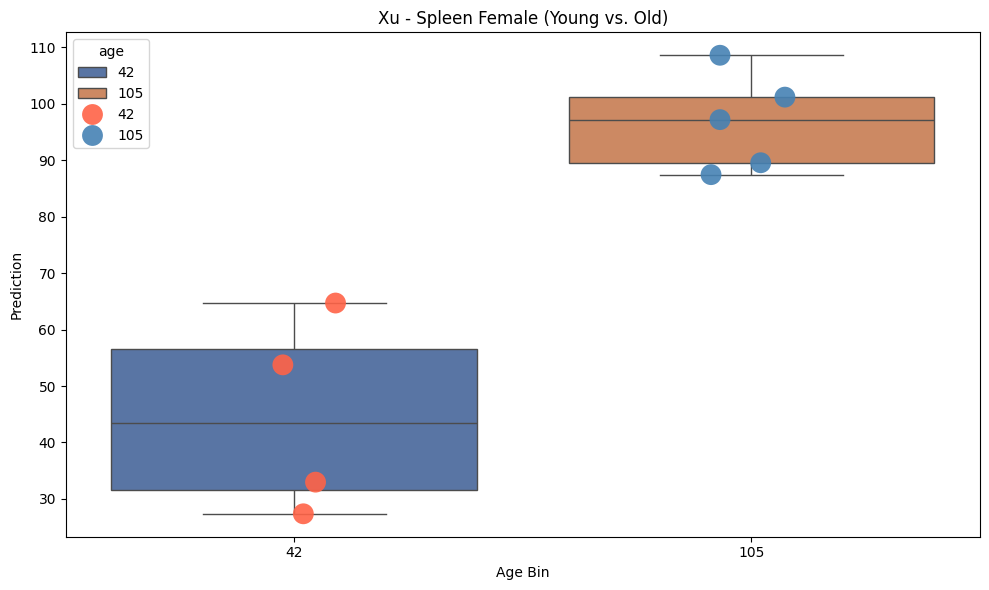

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu_spleen_female, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu_spleen_female,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Spleen Female (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_spleen_female[df_prediction_xu_spleen_female['age'] == 42]['y_pred']
group_16w = df_prediction_xu_spleen_female[df_prediction_xu_spleen_female['age'] == 105]['y_pred']

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Welch’s t-test p-value: 0.0049
Mann-Whitney U test p-value: 0.0159


# Muscle

In [ ]:
df_counts_muscle = pd.read_csv("../../Data_from_Others/AlanXu_Aging/CountsNormDESeq2_AlanXuAging_Muscle_250605.csv")

df_counts_muscle.head(5)

,Unnamed: 0,muscle_19,muscle_18,muscle_17,muscle_16,muscle_15,muscle_14,muscle_13,muscle_12,muscle_11,muscle_10,muscle_9,muscle_8,muscle_7,muscle_6,muscle_5,muscle_4,muscle_3,muscle_2,muscle_1
0,nadsyn1,66.433299,103.969816,90.104860,100.683910,83.784630,98.137717,61.731918,73.468377,76.799606,83.026927,115.317286,92.764969,130.539806,138.911607,84.235883,132.164531,95.681449,100.787544,79.278008
1,dnaja3,353.045530,365.627188,426.746627,368.215443,366.006541,418.504645,299.514121,359.010418,344.140008,261.996080,360.467319,324.677393,487.348608,411.178357,149.366720,299.435266,400.122425,329.102185,314.685153
2,f2r,7.592377,13.862642,12.514564,19.177888,13.229152,14.598999,9.145469,9.088871,19.442938,31.365728,4.838488,10.786624,7.735692,0.000000,6.947289,6.195212,11.307808,2.056889,14.561267
3,LOC107382877,17.082848,17.328303,5.005826,9.588944,6.614576,3.244222,2.286367,1.514812,17.498644,3.690086,33.869413,8.629299,0.000000,18.521548,36.473269,4.130142,8.698314,8.227555,11.325430
4,fezf1,7.592377,3.465661,0.000000,1.917789,2.204859,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.739663,0.000000,1.617919


In [ ]:
df_counts_muscle.rename(columns={"Unnamed: 0": "sample"}, inplace=True)

df_counts_muscle.head(3)

,sample,muscle_19,muscle_18,muscle_17,muscle_16,muscle_15,muscle_14,muscle_13,muscle_12,muscle_11,muscle_10,muscle_9,muscle_8,muscle_7,muscle_6,muscle_5,muscle_4,muscle_3,muscle_2,muscle_1
0,nadsyn1,66.433299,103.969816,90.104860,100.683910,83.784630,98.137717,61.731918,73.468377,76.799606,83.026927,115.317286,92.764969,130.539806,138.911607,84.235883,132.164531,95.681449,100.787544,79.278008
1,dnaja3,353.045530,365.627188,426.746627,368.215443,366.006541,418.504645,299.514121,359.010418,344.140008,261.996080,360.467319,324.677393,487.348608,411.178357,149.366720,299.435266,400.122425,329.102185,314.685153
2,f2r,7.592377,13.862642,12.514564,19.177888,13.229152,14.598999,9.145469,9.088871,19.442938,31.365728,4.838488,10.786624,7.735692,0.000000,6.947289,6.195212,11.307808,2.056889,14.561267


In [ ]:
df_counts_muscle.set_index("sample", inplace=True)

df_counts_muscle.head(3)

,muscle_19,muscle_18,muscle_17,muscle_16,muscle_15,muscle_14,muscle_13,muscle_12,muscle_11,muscle_10,muscle_9,muscle_8,muscle_7,muscle_6,muscle_5,muscle_4,muscle_3,muscle_2,muscle_1
sample,,,,,,,,,,,,,,,,,,,
nadsyn1,66.433299,103.969816,90.104860,100.683910,83.784630,98.137717,61.731918,73.468377,76.799606,83.026927,115.317286,92.764969,130.539806,138.911607,84.235883,132.164531,95.681449,100.787544,79.278008
dnaja3,353.045530,365.627188,426.746627,368.215443,366.006541,418.504645,299.514121,359.010418,344.140008,261.996080,360.467319,324.677393,487.348608,411.178357,149.366720,299.435266,400.122425,329.102185,314.685153
f2r,7.592377,13.862642,12.514564,19.177888,13.229152,14.598999,9.145469,9.088871,19.442938,31.365728,4.838488,10.786624,7.735692,0.000000,6.947289,6.195212,11.307808,2.056889,14.561267


In [ ]:
df_counts_muscle = df_counts_muscle.T

df_counts_muscle.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,3.796188,178.420859,0.0,3.796188,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,1.732830,232.199257,0.0,3.465661,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,15.017477,270.314579,0.0,10.011651,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168
muscle_16,100.683910,368.215443,19.177888,9.588944,1.917789,20.136782,0.0,0.0,59.451452,144.793052,...,9.588944,255.065906,0.0,3.835578,0.000000,63.287029,34.520198,1105.605224,466.022670,49.862508
muscle_15,83.784630,366.006541,13.229152,6.614576,2.204859,33.072880,0.0,0.0,97.013782,145.520673,...,8.819435,246.944172,0.0,4.409717,0.000000,50.711750,33.072880,1316.300633,474.044616,90.399206


In [ ]:
df_counts_metadata_muscle = df_counts_metadata[df_counts_metadata["tissue"] == "Muscle"]

df_counts_metadata_muscle.head(5)

,Sample.Name,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
23,muscle_19,SRR24062685,16w,RNA-Seq,300,5136081600,Dario Valenzano laboratory,PRJNA952180,SAMN34067691,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:27:00Z,1,GRZ-AD_8241_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062685.featureCounts,SRR24062685
24,muscle_18,SRR24062686,16w,RNA-Seq,300,5706151500,Dario Valenzano laboratory,PRJNA952180,SAMN34067690,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:31:00Z,1,GRZ-AD_8232_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062686.featureCounts,SRR24062686
25,muscle_17,SRR24062687,16w,RNA-Seq,300,4272510600,Dario Valenzano laboratory,PRJNA952180,SAMN34067689,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062687.featureCounts,SRR24062687
26,muscle_16,SRR24062688,16w,RNA-Seq,300,5033795700,Dario Valenzano laboratory,PRJNA952180,SAMN34067688,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8249_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062688.featureCounts,SRR24062688
27,muscle_15,SRR24062689,16w,RNA-Seq,300,5424135600,Dario Valenzano laboratory,PRJNA952180,SAMN34067687,Model organism or animal,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8225_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062689.featureCounts,SRR24062689


In [ ]:
df_counts_metadata_muscle.set_index("Sample.Name", inplace=True)

df_counts_metadata_muscle.head(5)

,Run,age,Assay.Type,AvgSpotLen,Bases,BIOMATERIAL_PROVIDER,BioProject,BioSample,BioSampleModel,Bytes,...,ReleaseDate,create_date,version,Sample_info,sex,SRA.Study,strain,tissue,file,lib
Sample.Name,,,,,,,,,,,,,,,,,,,,,
muscle_19,SRR24062685,16w,RNA-Seq,300,5136081600,Dario Valenzano laboratory,PRJNA952180,SAMN34067691,Model organism or animal,1851655279,...,2023-06-20T00:00:00Z,2023-04-04T11:27:00Z,1,GRZ-AD_8241_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062685.featureCounts,SRR24062685
muscle_18,SRR24062686,16w,RNA-Seq,300,5706151500,Dario Valenzano laboratory,PRJNA952180,SAMN34067690,Model organism or animal,2090590736,...,2023-06-20T00:00:00Z,2023-04-04T11:31:00Z,1,GRZ-AD_8232_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062686.featureCounts,SRR24062686
muscle_17,SRR24062687,16w,RNA-Seq,300,4272510600,Dario Valenzano laboratory,PRJNA952180,SAMN34067689,Model organism or animal,1545160147,...,2023-06-20T00:00:00Z,2023-04-04T11:28:00Z,1,GRZ-AD_8273_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062687.featureCounts,SRR24062687
muscle_16,SRR24062688,16w,RNA-Seq,300,5033795700,Dario Valenzano laboratory,PRJNA952180,SAMN34067688,Model organism or animal,1824875900,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8249_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062688.featureCounts,SRR24062688
muscle_15,SRR24062689,16w,RNA-Seq,300,5424135600,Dario Valenzano laboratory,PRJNA952180,SAMN34067687,Model organism or animal,1977691831,...,2023-06-20T00:00:00Z,2023-04-04T11:29:00Z,1,GRZ-AD_8225_16w_Female_Muscle,female,SRP430823,GRZ-AD,Muscle,SRR24062689.featureCounts,SRR24062689


In [ ]:
df_counts_muscle = df_counts_muscle.loc[df_counts_metadata_muscle.index.tolist(),]

df_counts_muscle.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,3.796188,178.420859,0.0,3.796188,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,1.732830,232.199257,0.0,3.465661,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,15.017477,270.314579,0.0,10.011651,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168
muscle_16,100.683910,368.215443,19.177888,9.588944,1.917789,20.136782,0.0,0.0,59.451452,144.793052,...,9.588944,255.065906,0.0,3.835578,0.000000,63.287029,34.520198,1105.605224,466.022670,49.862508
muscle_15,83.784630,366.006541,13.229152,6.614576,2.204859,33.072880,0.0,0.0,97.013782,145.520673,...,8.819435,246.944172,0.0,4.409717,0.000000,50.711750,33.072880,1316.300633,474.044616,90.399206


In [ ]:
df_counts_muscle["tissue"] = df_counts_metadata_muscle["tissue"].tolist()
df_counts_muscle["age"] = df_counts_metadata_muscle["age"].tolist()
df_counts_muscle["sex"] = df_counts_metadata_muscle["sex"].tolist()

df_counts_muscle.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,3.796188,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979,Muscle,16w,female
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,3.465661,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417,Muscle,16w,female
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,10.011651,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168,Muscle,16w,female


In [ ]:
age_mapping = {
    "6w": 42,
    "16w": 105
}

df_counts_muscle["new_age"] = df_counts_muscle["age"].map(age_mapping)

df_counts_muscle.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979,Muscle,16w,female,105
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417,Muscle,16w,female,105
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168,Muscle,16w,female,105
muscle_16,100.683910,368.215443,19.177888,9.588944,1.917789,20.136782,0.0,0.0,59.451452,144.793052,...,0.000000,63.287029,34.520198,1105.605224,466.022670,49.862508,Muscle,16w,female,105
muscle_15,83.784630,366.006541,13.229152,6.614576,2.204859,33.072880,0.0,0.0,97.013782,145.520673,...,0.000000,50.711750,33.072880,1316.300633,474.044616,90.399206,Muscle,16w,female,105


In [ ]:
df_counts_muscle_age = df_counts_muscle.copy()

df_counts_muscle_age = df_counts_muscle_age.iloc[:,:-4]

df_counts_muscle_age.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107377225,plekhg1,LOC107373049,LOC107375201,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,3.796188,178.420859,0.0,3.796188,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,1.732830,232.199257,0.0,3.465661,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,15.017477,270.314579,0.0,10.011651,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168
muscle_16,100.683910,368.215443,19.177888,9.588944,1.917789,20.136782,0.0,0.0,59.451452,144.793052,...,9.588944,255.065906,0.0,3.835578,0.000000,63.287029,34.520198,1105.605224,466.022670,49.862508
muscle_15,83.784630,366.006541,13.229152,6.614576,2.204859,33.072880,0.0,0.0,97.013782,145.520673,...,8.819435,246.944172,0.0,4.409717,0.000000,50.711750,33.072880,1316.300633,474.044616,90.399206


In [ ]:
df_counts_muscle_age["age"] = df_counts_muscle["new_age"].tolist()

In [ ]:
df_counts_muscle_male = df_counts_muscle[df_counts_muscle["sex"] == "male"]

df_counts_muscle_male.head(3)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
muscle_14,98.137717,418.504645,14.598999,3.244222,0.0,21.087443,0.0,0.0,103.815106,148.423159,...,0.0,32.442221,48.663331,1270.923990,355.242315,80.294496,Muscle,16w,male,105
muscle_13,61.731918,299.514121,9.145469,2.286367,0.0,25.150041,0.0,0.0,70.877387,173.763917,...,0.0,43.440979,52.586449,1404.972726,554.444078,34.295510,Muscle,16w,male,105
muscle_12,73.468377,359.010418,9.088871,1.514812,0.0,22.722178,0.0,0.0,81.799842,146.936753,...,0.0,28.781426,37.870297,1383.023256,424.904735,80.285030,Muscle,16w,male,105


In [ ]:
df_counts_muscle_male_xu = df_counts_muscle_male.iloc[:,:-4]

df_counts_muscle_male_xu["age"] = df_counts_muscle_male["new_age"].tolist()

/tmp/ipykernel_433582/1622213909.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_muscle_male_xu["age"] = df_counts_muscle_male["new_age"].tolist()


In [ ]:
df_counts_muscle_female = df_counts_muscle[df_counts_muscle["sex"] == "female"]

df_counts_muscle_female.head(5)

sample,nadsyn1,dnaja3,f2r,LOC107382877,fezf1,srbd1,LOC107373267,LOC107384240,serp1,scarb2,...,LOC107384697,umodl1,cryz,LOC107397181,pelo,mrpl35,tissue,age,sex,new_age
muscle_19,66.433299,353.045530,7.592377,17.082848,7.592377,30.369508,0.0,0.0,60.739016,177.471812,...,1.898094,51.248545,34.165696,1416.927358,403.345028,39.859979,Muscle,16w,female,105
muscle_18,103.969816,365.627188,13.862642,17.328303,3.465661,31.190945,0.0,0.0,65.847550,168.084536,...,0.000000,97.904910,41.587927,1173.992510,473.929080,46.786417,Muscle,16w,female,105
muscle_17,90.104860,426.746627,12.514564,5.005826,0.000000,25.029128,0.0,0.0,95.110685,118.888357,...,0.000000,72.584470,30.034953,1202.649587,438.009735,52.561168,Muscle,16w,female,105
muscle_16,100.683910,368.215443,19.177888,9.588944,1.917789,20.136782,0.0,0.0,59.451452,144.793052,...,0.000000,63.287029,34.520198,1105.605224,466.022670,49.862508,Muscle,16w,female,105
muscle_15,83.784630,366.006541,13.229152,6.614576,2.204859,33.072880,0.0,0.0,97.013782,145.520673,...,0.000000,50.711750,33.072880,1316.300633,474.044616,90.399206,Muscle,16w,female,105


In [ ]:
df_counts_muscle_female_xu = df_counts_muscle_female.iloc[:,:-4]

df_counts_muscle_female_xu["age"] = df_counts_muscle_female["new_age"].tolist()

/tmp/ipykernel_433582/1377032716.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_counts_muscle_female_xu["age"] = df_counts_muscle_female["new_age"].tolist()


### Muscle Atlas

In [ ]:
muscle_df = combined_df.loc[combined_df.iloc[:,-2] == "Muscle"]

muscle_df.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,M,Muscle,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,M,Muscle,52
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,F,Muscle,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,F,Muscle,155


In [ ]:
muscle_df_age = muscle_df.iloc[:,:-3]

muscle_df_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,700.569024,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,755.819358,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,642.836078,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,468.174077,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,706.723146,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427


In [ ]:
muscle_df_age["age"] = muscle_df["age_days"].tolist()

In [ ]:
muscle_atlas_plus_xu = pd.concat([muscle_df_age, df_counts_muscle_age], axis=0)

muscle_atlas_plus_xu.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,52


In [ ]:
muscle_atlas_xu_data = muscle_atlas_plus_xu.values

In [ ]:
X, y = muscle_atlas_xu_data[:,:-1], muscle_atlas_xu_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

#### Best parameters

##### alpha = 0.01, l1_ratio 0.4

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=0.4, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 12.085
Pearson correlation: 0.929
R-squared: 0.857
Average number of non-zero coefficients: 815.36


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': muscle_atlas_plus_xu["age"].tolist(),
}, index=muscle_atlas_plus_xu.index.tolist())

df_prediction.head(10)

,y_pred,age
A13_1,135.834742,134
A14_1,139.570072,147
A15_1,88.394583,52
A16_1,122.931983,103
B13_1,141.986660,155
B14_1,55.760321,77
B15_1,121.640648,102
B16_1,113.977563,133
C13_1,150.629105,134
C14_1,47.748073,49


In [ ]:
df_prediction_xu = df_prediction.loc[df_counts_muscle_age.index.tolist(), ]

df_prediction_xu.head(5)

,y_pred,age
muscle_19,96.465037,105
muscle_18,100.385867,105
muscle_17,95.812098,105
muscle_16,103.262433,105
muscle_15,91.658810,105


In [ ]:
df_prediction_xu.to_csv("./Xu_muscle_sex_combined.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

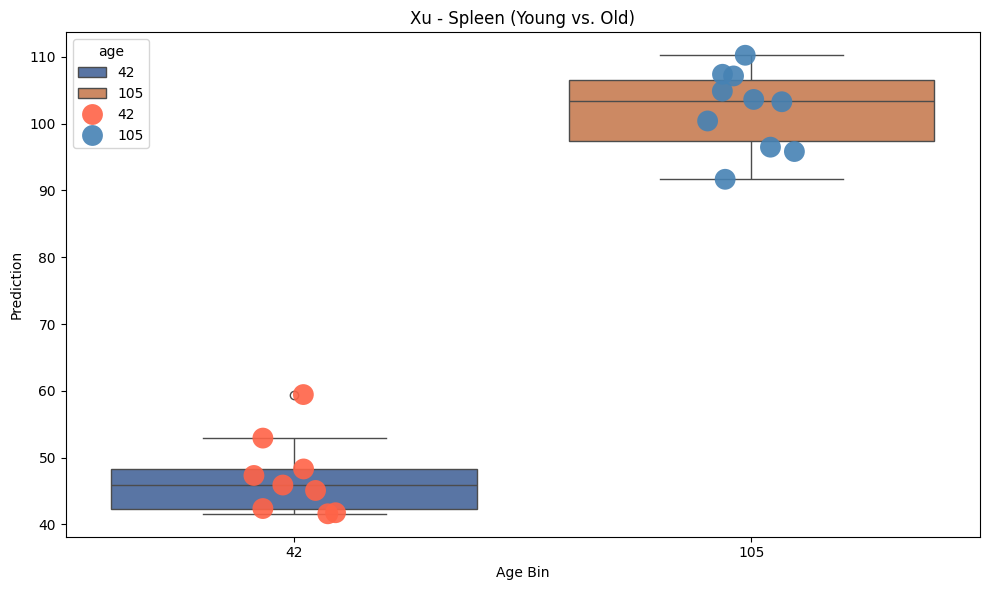

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Spleen (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu[df_prediction_xu['age'] == 42]['y_pred']
group_16w = df_prediction_xu[df_prediction_xu['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 9
Group 16w size: 10
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0003


#### Male

In [ ]:
muscle_df_male = muscle_df[muscle_df["sex"] == "M"]

muscle_df_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,M,Muscle,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,M,Muscle,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,M,Muscle,52
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192,M,Muscle,102
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520,M,Muscle,133


In [ ]:
muscle_df_male_age = muscle_df_male.iloc[:,:-3]

muscle_df_male_age.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim6,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,700.569024,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,755.819358,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,642.836078,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,202.958024,102.142274,883.464341,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,323.047736,87.246469,483.392597,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520


In [ ]:
muscle_df_male_age["age"] = muscle_df_male["age_days"].tolist()

In [ ]:
muscle_atlas_plus_xu_male = pd.concat([muscle_df_male_age, df_counts_muscle_male_xu], axis=0)

muscle_atlas_plus_xu_male.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A13_1,2.350903,453.724234,134.001458,712.323538,481.935067,1024.993606,886.290343,2868.101375,759.341594,702.919927,...,51.719861,1036.748120,96.387013,883.939440,14.105417,1288.294716,1539.841312,298.564651,347.933609,134
A14_1,1.880148,327.145692,174.853732,627.969318,370.389089,844.186298,789.662016,2120.806558,693.774486,667.452418,...,43.243396,960.755453,58.284577,889.309842,13.161034,1154.410662,1583.084328,454.995733,344.067021,147
A15_1,3.992771,419.240920,139.746973,778.590280,395.284296,934.308337,527.045728,2367.713007,842.474611,491.110792,...,31.942165,914.344483,155.718056,914.344483,11.978312,1094.019163,1481.317918,235.573469,331.399966,52
B15_1,9.285661,508.058322,78.264859,967.035292,348.875558,1122.238487,1540.093242,1349.073926,3329.572815,1822.642649,...,102.142274,883.464341,423.160848,902.035663,19.897846,687.138932,1776.214343,244.080238,241.427192,102
B16_1,2.358013,544.700927,77.814418,811.156359,261.739406,1436.029716,929.056992,1794.447642,1973.656605,1058.747689,...,87.246469,483.392597,134.406722,728.625915,21.222114,839.452511,1494.980033,162.702874,282.961520,133


In [ ]:
muscle_atlas_plus_xu_male_data = muscle_atlas_plus_xu_male.values

In [ ]:
X, y = muscle_atlas_plus_xu_male_data[:,:-1], muscle_atlas_plus_xu_male_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

### Best parameters

##### alpha = 0.01, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 9.497
Pearson correlation: 0.962
R-squared: 0.922
Average number of non-zero coefficients: 61.40


In [ ]:
# Create a DataFrame
df_prediction_male = pd.DataFrame({
    'y_pred': y_pred,
    'age': muscle_atlas_plus_xu_male["age"].tolist(),
}, index=muscle_atlas_plus_xu_male.index.tolist())

df_prediction_male.head(10)

,y_pred,age
A13_1,126.313973,134
A14_1,152.172598,147
A15_1,73.113194,52
B15_1,105.689861,102
B16_1,116.729965,133
C13_1,153.944912,134
C14_1,53.727903,49
C16_1,59.941455,47
D14_1,107.430690,103
D16_1,158.900505,152


In [ ]:
df_prediction_xu_muscle_male = df_prediction_male.loc[df_counts_muscle_male.index.tolist(), ]

df_prediction_xu_muscle_male

,y_pred,age
muscle_14,101.762374,105
muscle_13,104.601247,105
muscle_12,103.253400,105
muscle_11,103.303446,105
muscle_10,103.114815,105
muscle_5,27.655822,42
muscle_4,43.606824,42
muscle_3,40.987014,42
muscle_2,44.511079,42
muscle_1,48.128758,42


In [ ]:
df_prediction_xu_muscle_male["weeks"] = df_counts_muscle_male["age"].tolist()

In [ ]:
df_prediction_xu_muscle_male.to_csv("./Xu_muscle_sex_male.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

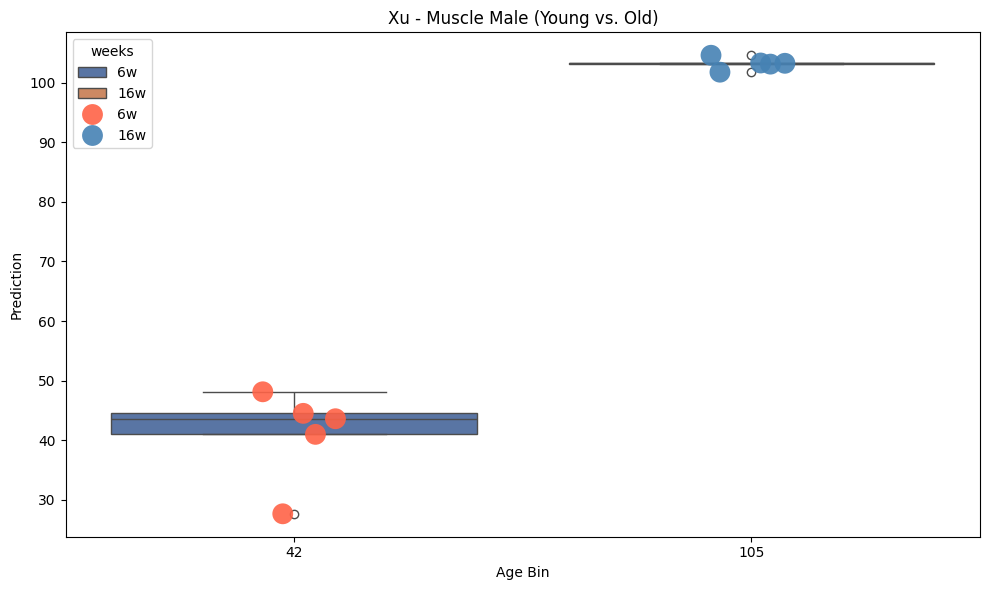

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='weeks', data=df_prediction_xu_muscle_male, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='weeks',
    data=df_prediction_xu_muscle_male,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Muscle Male (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_muscle_male[df_prediction_xu_muscle_male['age'] == 42]['y_pred']
group_16w = df_prediction_xu_muscle_male[df_prediction_xu_muscle_male['age'] == 105]['y_pred']

print("Group 6w size:", len(group_6w))
print("Group 16w size:", len(group_16w))

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Group 6w size: 5
Group 16w size: 5
Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0079


#### Female

In [ ]:
muscle_df_female = muscle_df[muscle_df["sex"] == "F"]

muscle_df_female.head(5)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,sex,tissue,age_days
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,F,Muscle,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,F,Muscle,155
B14_1,11.425531,536.999954,260.502106,539.285061,429.599964,1042.008422,767.795680,1631.565819,918.612688,431.885070,...,89.119141,966.599918,68.553186,902.616945,1544.731784,404.463795,379.327627,F,Muscle,77
C15_1,2.699865,448.177510,110.694445,693.865182,315.884149,1158.241879,674.966130,1803.509499,1241.937679,683.065724,...,126.893632,664.166672,29.698510,1347.232395,1892.605028,350.982388,348.282523,F,Muscle,134
D13_1,97.927266,349.422289,166.921476,750.033831,454.026414,750.033831,843.509857,2152.174227,934.760264,600.917313,...,129.085941,721.100775,28.933056,794.546225,1531.226337,344.971050,338.294191,F,Muscle,102


In [ ]:
muscle_df_female_age = muscle_df_female.iloc[:,:-3]

muscle_df_female_age["age"] = muscle_df_female["age_days"].tolist()

In [ ]:
muscle_atlas_plus_xu_female = pd.concat([muscle_df_female_age, df_counts_muscle_female_xu], axis=0)

muscle_atlas_plus_xu_female.head(3)

,a1cf,aaas,aacs,aadat,aaed1,aagab,aak1,aamdc,aamp,aar2,...,zswim7,zswim8,zufsp,zw10,zwilch,zyg11b,zyx,zzef1,zzz3,age
A16_1,1.631269,482.855494,84.825965,908.616589,363.772889,944.504497,885.778829,2233.206661,1295.227238,750.383538,...,40.781714,610.094442,138.657828,614.988248,8.156343,960.817183,1249.551718,107.663725,438.811243,103
B13_1,1.771236,504.802247,99.189213,825.395955,480.004944,1013.146966,998.977078,2463.789213,981.264719,793.513708,...,83.248090,825.395955,123.986517,683.697078,8.856180,1225.695280,1712.785168,258.600449,356.018427,155
B14_1,11.425531,536.999954,260.502106,539.285061,429.599964,1042.008422,767.795680,1631.565819,918.612688,431.885070,...,29.706380,792.931848,89.119141,966.599918,68.553186,902.616945,1544.731784,404.463795,379.327627,77


In [ ]:
muscle_atlas_plus_xu_female_data = muscle_atlas_plus_xu_female.values

In [ ]:
X, y = muscle_atlas_plus_xu_female_data[:,:-1], muscle_atlas_plus_xu_female_data[:,-1]

In [ ]:
seed = 42

# Define the parameter grid
param_grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0],
    'l1_ratio': np.arange(0, 1.1, 0.1)
}

# Define the model
model = ElasticNet(max_iter=10000, random_state=42)

# Define Leave-One-Out cross-validation
loo = LeaveOneOut()

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the GridSearchCV
grid_search.fit(X_scaled, y)

# Get the best parameters
best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

# Train the model with the best parameters using Leave-One-Out cross-validation
y_true = []
y_pred = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'], max_iter=100000, random_state=seed)
    best_model.fit(X_train_scaled, y_train)

    y_test_pred = best_model.predict(X_test_scaled)

    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"Mean MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

## Best parameters

#### alpha = 0.01, l1_ratio = 1.0

In [ ]:
# Set a seed for reproducibility
seed = 42

# Leave-One-Out cross-validation
loo = LeaveOneOut()

# Initialize lists to store actual and predicted values
y_true = []
y_pred = []
non_zero_coefs_list = []

# Loop over each train-test split
for train_index, test_index in loo.split(X):
    # Split the data
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define and train the model with a random state
    model = ElasticNet(alpha=0.01, l1_ratio=1.0, max_iter=100000, random_state=seed)
    model.fit(X_train_scaled, y_train)

    # Get the number of non-zero coefficients
    non_zero_coefs = np.sum(model.coef_ != 0)
    non_zero_coefs_list.append(non_zero_coefs)

    # Make prediction on the test set
    y_test_pred = model.predict(X_test_scaled)

    # Store the actual and predicted values
    y_true.append(y_test[0])
    y_pred.append(y_test_pred[0])

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calculate the Pearson correlation coefficient
pearson_corr, _ = pearsonr(y_true, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_true, y_pred)

# Calculate the mean absolute error
mae = mean_absolute_error(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"R-squared: {r_squared:.3f}")

# Print average and total non-zero coefficients across all LOO iterations
avg_non_zero_coefs = np.mean(non_zero_coefs_list)
print(f"Average number of non-zero coefficients: {avg_non_zero_coefs:.2f}")

MAE: 9.687
Pearson correlation: 0.950
R-squared: 0.897
Average number of non-zero coefficients: 52.03


In [ ]:
# Create a DataFrame
df_prediction = pd.DataFrame({
    'y_pred': y_pred,
    'age': muscle_atlas_plus_xu_female["age"].tolist(),
}, index=muscle_atlas_plus_xu_female.index.tolist())

df_prediction.head(10)

,y_pred,age
A16_1,120.576876,103
B13_1,157.779262,155
B14_1,69.520947,77
C15_1,118.718372,134
D13_1,106.575221,102
D15_1,104.560302,78
E14_1,154.305576,147
F14_1,144.544532,147
F16_1,67.823231,49
G13_1,96.754499,102


In [ ]:
df_prediction_xu_muscle_female = df_prediction.loc[df_counts_muscle_female.index.tolist(), ]

df_prediction_xu_muscle_female

,y_pred,age
muscle_19,100.619838,105
muscle_18,101.754278,105
muscle_17,98.155391,105
muscle_16,118.658565,105
muscle_15,101.820169,105
muscle_9,44.041278,42
muscle_8,47.365127,42
muscle_7,42.477394,42
muscle_6,54.189467,42


In [ ]:
df_prediction_xu_muscle_female.to_csv("./Xu_muscle_sex_female.csv", sep="\t")

/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/site-packages/seaborn/_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lajoyce/Documents/USQIS_2023/qiskit/lib/python3.10/sit

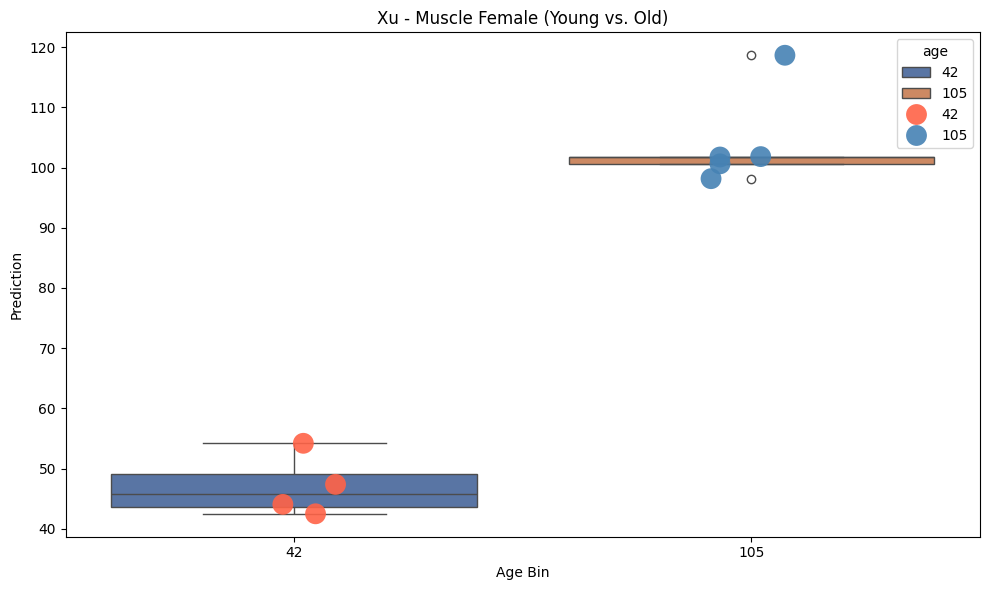

In [ ]:
# Set a seed for reproducibility
np.random.seed(42)

# Create the box plot
plt.figure(figsize=(10, 6))
box = sns.boxplot(x='age', y='y_pred', hue='age', data=df_prediction_xu_muscle_female, palette='deep')

# Add data points
#strip = sns.stripplot(x='feed', y='prediction', hue='feed', data=liver_male_age_predictions_young_het,
#                      palette='deep', dodge=True, alpha=0.9, jitter=True, size=15)# Example of custom colors for each feed category

custom_palette = ['#FF6347', '#4682B4', '#32CD32', '#FFD700']  # Use desired hex color codes

# Add data points with custom colors
strip = sns.stripplot(
    x='age',
    y='y_pred',
    hue='age',
    data=df_prediction_xu_muscle_female,
    palette=custom_palette,  # Custom color palette
    dodge=False,
    alpha=0.9,
    jitter=True,
    size=15
)

# Remove the legend if not needed
#strip.legend_.remove()

# Customize the plot
plt.title('Xu - Muscle Female (Young vs. Old)')
plt.xlabel('Age Bin')
plt.ylabel('Prediction')

# Remove the grid
plt.grid(False)

#plt.savefig("/mnt/c/Users/lajoy/Downloads/mating_jing/liver_mating_young_vs_old_combined.svg", dpi=300, bbox_inches="tight")

plt.tight_layout()
#plt.savefig("/home/lajoyce/killifish_atlas/revisions/plots/brain_female_atlas_vs_xu_EN.png")

# Show the plot
plt.show()

In [ ]:
# Split data by age group
group_6w = df_prediction_xu_muscle_female[df_prediction_xu_muscle_female['age'] == 42]['y_pred']
group_16w = df_prediction_xu_muscle_female[df_prediction_xu_muscle_female['age'] == 105]['y_pred']

# Welch’s t-test (does not assume equal variance)
t_stat, p_val_ttest = ttest_ind(group_6w, group_16w, equal_var=False)

# Mann-Whitney U test (non-parametric)
u_stat, p_val_mannwhitney = mannwhitneyu(group_6w, group_16w, alternative='two-sided')

print(f"Welch’s t-test p-value: {p_val_ttest:.4f}")
print(f"Mann-Whitney U test p-value: {p_val_mannwhitney:.4f}")

Welch’s t-test p-value: 0.0000
Mann-Whitney U test p-value: 0.0159
